# 第十一週：Text Embeddings

本週課程為「Text Embeddings」，主要會使用到gensim套件來實現自行訓練word2vec模型以及使用預訓練word2vec模型，以及透過sentence-transformers套件和API取得embeddings。

## ＃大綱

1. 研究背景：
近期AI的發展快速帶動 NVIDIA、AI 晶片、GPU、AI 伺服器與台灣供應鏈成為熱門討論議題。在 PTT 中，這類話題不只涉及科技發展，也常延伸到股價、財報、台積電、廣達、緯創、鴻海等投資與產業鏈討論。

2. 研究動機：PTT 不同看板的討論角度不同，Gossiping 較偏向新聞事件、人物形象與社會情緒；Stock 則較偏向股價、財報、產業鏈與投資判斷，因此本次讀書會想了解同樣是 NVIDIA 與 AI 晶片議題，兩個看板的討論焦點是否不同。

3. 研究主題：以PTT討論資料 分析NVIDIA在AI熱潮中的認知差異：比較 Gossiping 與 Stock 看板之主題與情緒

4. 研究方法：
*   本研究使用 Text Embeddings 相關方法進行分析，包括 Word2Vec 與 BERT Embeddings。*   Word2Vec 用來觀察「輝達」、「晶片」、「台積電」、「AI伺服器」等詞彙的語意關聯
*   BERT Embeddings 則用來將文章轉為語意向量，並透過分類模型比較 Gossiping 與 Stock 的討論差異。
     *   自行訓練Word2Vec模型
     *   Transformers Embeddings
         *    使用embedding 做 NLP 任務
         *    找相似文章

5. 研究問題：
*   RQ1：PTT 使用者討論 NVIDIA 與 AI 晶片熱潮時，主要形成哪些主題？
*   RQ2：Gossiping 與 Stock 對 NVIDIA 的討論焦點是否不同？（第七周文件分類延伸）
*   RQ3：PTT 對 NVIDIA 與 AI 晶片熱潮的投資態度偏向看好、觀望，還是看壞／泡沫疑慮？


## 前製作業

### 1.套件安裝

In [ ]:
# 連接雲端資料夾
import os

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11') #切換該目錄
os.listdir() #確認目錄內容

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['TaipeiSansTCBeta-Regular.ttf',
 'raw_data',
 'dict',
 'tmunlp_1.6B_WB_50dim_2020v1.bin',
 'S3_id.csv',
 'S3主題.gdoc',
 '.ipynb_checkpoints',
 'S3-2.csv',
 'RQ2_BERT_board_classification_result.csv',
 'RQ2_wrong_cases.csv',
 'RQ3_sentence_investment_stance.csv',
 'RQ3_article_investment_stance.csv',
 'w11_embeddings.ipynb']

In [ ]:
!pip install jieba
!pip install "gensim==4.3.3" "spacy==3.7.2" "thinc==8.2.2"

如果安裝套件時遇到跟 numpy 相關錯誤的話，可以嘗試執行以下程式碼

In [ ]:
# 先清除舊的 numpy
# !pip uninstall -y numpy

# 安裝對應版本
# !pip install numpy==1.26.4 gensim==4.3.3 spacy==3.7.2 thinc==8.2.2

# 強制重啟 Runtime
# import os
# os.kill(os.getpid(), 9)

In [ ]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors

from gensim.models import Word2Vec

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compil

### 2.資料前處理

In [ ]:
# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')
jieba.load_userdict('./dict/user_dict.txt')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定停用字
stop_words = [
    "連結",
    "轉載",
    "備註",
    "請放違者",
    "網站",
    "刪除",
    "新聞",
    "這項",
    "錯誤",
    "記者",
    "比較",
    "優於",
    "有人",
    "上班",
    "補充",
    "時間",
    "張券",
    "張券增",
    "協助",
    "署名",
    "發布",
    "第一",
    "原本",
    "內文",
    "仟元",
    "大學",
    "處於",
    "近年",
    "代表",
    "做出",
    "達成",
    "包含",
    "詐騙",
    "來源",
    "八卦","心得","文章","有沒有","執行","方式"
]

# 合併 stopwords，並移除重複值
stopWords = list(set(stopWords + stop_words))

# 確認停用字是否有成功加入
print("停用字數量：", len(stopWords))
print("手動新增停用字：", stop_words)

Building prefix dict from /content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11/dict/dict.txt.big ...
Dumping model to file cache /tmp/jieba.u9ba51f89eaf59b988c28628abc3f894d.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.u9ba51f89eaf59b988c28628abc3f894d.cache
Loading model cost 3.810 seconds.
DEBUG:jieba:Loading model cost 3.810 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


停用字數量： 1741
手動新增停用字： ['連結', '轉載', '備註', '請放違者', '網站', '刪除', '新聞', '這項', '錯誤', '記者', '比較', '優於', '有人', '上班', '補充', '時間', '張券', '張券增', '協助', '署名', '發布', '第一', '原本', '內文', '仟元', '大學', '處於', '近年', '代表', '做出', '達成', '包含', '詐騙', '來源', '八卦', '心得', '文章', '有沒有', '執行', '方式']


In [ ]:
# 補進 user_dict 的主題詞
topic_words = [
    "NVIDIA",
    "輝達",
    "黃仁勳",
    "AI",
    "AI晶片",
    "AI伺服器",
    "GPU",
    "GB200",
    "GB300",
    "H100",
    "H200",
    "B200",
    "BLACKWELL",
    "COWOS",
    "台積電",
    "廣達",
    "緯創",
    "緯穎",
    "鴻海",
    "奇鋐",
    "雙鴻",
    "健策",
    "台達電"
]

for w in topic_words:
    jieba.add_word(w)

In [ ]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [ ]:
# 讀入中文資料集
origin_data = pd.read_csv('./S3-2.csv')

In [ ]:
# 資料前處理

import re

# 去除一些不需要的欄位
metaData = origin_data.drop(['artPoster'], axis=1)

# 文章斷句前處理
metaData['sentence'] = metaData['artContent'].astype(str).str.replace(r'\n\n', '。', regex=True)
metaData['sentence'] = metaData['sentence'].str.replace(r'\n', '', regex=True)

# 依照標點符號切句
metaData['sentence'] = metaData['sentence'].str.split("[,，。！!？?]{1,}")
metaData = metaData.explode('sentence').reset_index(drop=True)

# 保留中文、英文、數字
# 例如：AI、NVIDIA、NVDA、GPU、GB200、H100、CoWoS 都會保留
metaData['sentence'] = metaData['sentence'].apply(
    lambda x: re.sub(r'[^\u4e00-\u9fffA-Za-z0-9]+', '', str(x))
)

# 統一英文大小寫，建議轉成大寫
# 這樣 ai、Ai、AI 都會變成 AI；nvidia、Nvidia 都會變成 NVIDIA
metaData['sentence'] = metaData['sentence'].str.upper()

# 常見詞統一
replace_dict = {
    "NVDA": "輝達",
    "NVDIA": "輝達",
    "NVIDIA": "輝達",
    "老黃": "黃仁勳",
    "仁勳": "黃仁勳",
    "JENSEN": "黃仁勳",
    "TSMC": "台積電",
    "CO WOS": "COWOS",
    "COWOS": "COWOS",
    "AI SERVER": "AI伺服器",
    "超微":"美超微"
}

for old, new in replace_dict.items():
    metaData["sentence"] = metaData["sentence"].str.replace(old, new, regex=False)


# 斷詞
metaData['word'] = metaData.sentence.apply(getToken)
sents = metaData['word'].to_list()

# 移除斷詞後沒有內容的資料
metaData = metaData[metaData['word'].apply(len) > 0]

metaData.head(10)

,system_id,content,artTitle,artContent,artUrl,artCatagory,artDate,embeddings,content_length,sentence,word
0,1,台股大盤漲基層無感雞腿便當130 帳單 聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感...,台股大盤漲基層無感雞腿便當130 帳單,聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感 2026 01 01 08 32 聯合...,https://www.ptt.cc/bbs/Gossiping/M.1767227804....,Gossiping,2026-01-01 08:36:41,[-3.33245397e-02 -2.62892455e-01 4.87256311e-...,734,聯合台股大盤漲基層無感雞腿便當130帳單漲有感202601010832聯合報葉德正新北即時報...,"[聯合, 台股, 大盤, 基層, 無感, 雞腿, 便當, 130, 帳單, 有感, 2026..."
1,2,問卦 美國版的我們這一家這樣行嗎 美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美...,問卦 美國版的我們這一家這樣行嗎,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,https://www.ptt.cc/bbs/Gossiping/M.1767228682....,Gossiping,2026-01-01 08:51:20,[-2.14858159e-01 -2.34645665e-01 3.45769912e-...,913,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的SUGARDADDY唯一的金主與規矩...,"[美國, 以色列, 日本, 南韓, 台灣, 關係網, 親屬關係, 區分, 美國, 家族, S..."
2,3,問卦 韌性是可以多萬用 不膩嗎 干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台...,問卦 韌性是可以多萬用 不膩嗎,干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災...,https://www.ptt.cc/bbs/Gossiping/M.1767230877....,Gossiping,2026-01-01 09:27:55,[-2.70269006e-01 -2.89724499e-01 1.88032672e-...,125,干你中分龜頭都2026了還在韌性台灣2025經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力...,"[中分, 龜頭, 2026, 還在, 韌性, 台灣, 2025, 經歷, 賤賣, 台積電, ..."
3,4,台積電高雄廠2奈米量產市府 高雄躍升全 1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台...,台積電高雄廠2奈米量產市府 高雄躍升全,1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台積電高雄廠2奈米量產 市府 高雄躍升全球...,https://www.ptt.cc/bbs/Gossiping/M.1767236731....,Gossiping,2026-01-01 11:05:29,[ 1.22327559e-01 -1.93230018e-01 2.29706198e-...,934,1媒體來源自由時報2葛祐豪3完整標題台積電高雄廠2奈米量產市府高雄躍升全球先進半導體製程關鍵...,"[媒體, 自由, 時報, 葛祐豪, 完整, 台積電, 高雄廠, 奈米, 量產, 市府, 高雄..."
4,5,RE 台股大盤漲基層無感雞腿便當130 帳單 不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母...,RE 台股大盤漲基層無感雞腿便當130 帳單,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,https://www.ptt.cc/bbs/Gossiping/M.1767238166....,Gossiping,2026-01-01 11:29:24,[-2.29699641e-01 -3.94749165e-01 1.36889040e-...,145,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,"[不存, 大雄, 廢物, 辦法, 選擇, 父母, 選擇, 存股, 好好, 選積, 電子, 股..."
5,6,RE 問卦 經濟學人 台灣應思考開戰後美不出兵應 早在川普上任之前就有說法好嗎 到底為什麼還...,RE 問卦 經濟學人 台灣應思考開戰後美不出兵應,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...,https://www.ptt.cc/bbs/Gossiping/M.1767239036....,Gossiping,2026-01-01 11:43:54,[-7.74645329e-01 -2.95131892e-01 -2.30428074e-...,155,早在川普上任之前就有說法好嗎到底為什麼還在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭都還...,"[早在川普, 上任, 說法, 還在, 美國, 美國, 歷史, 戰爭, 發財, 烏克蘭, 都還..."
6,7,台積電高雄2奈米廠正式量產新增2匝道及 1 媒體來源 聯合 2 2026 01 01 10 ...,台積電高雄2奈米廠正式量產新增2匝道及,1 媒體來源 聯合 2 2026 01 01 10 56 聯合報 徐白櫻 高雄即時報導 3 ...,https://www.ptt.cc/bbs/Gossiping/M.1767245019....,Gossiping,2026-01-01 13:23:37,[ 5.19942567e-02 -1.67467713e-01 5.22609614e-...,851,1媒體來源聯合2202601011056聯合報徐白櫻高雄即時報導3完整標題台積電高雄2奈米廠...,"[媒體, 聯合, 2202601011056, 聯合報, 徐白, 櫻高雄, 即時, 完整, ..."
7,8,問卦 2025台灣有完成什麼大事嗎 一整年如果認真應該可以完成不少事 何況預算又創新高 不然...,問卦 2025台灣有完成什麼大事嗎,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...,https://www.ptt.cc/bbs/Gossiping/M.1767245060....,Gossiping,2026-01-01 13:24:18,[-2.65180469e-01 -3.13053519e-01 2.11296439e-...,220,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,"[整年, 預算, 又創新高, 八年, 累積下來, 建設, 完工, 硬體, 建設, 印象, 淡..."
8,9,RE 新規必看 千坪大樓必須裝太陽光電 要能承受17級強陣風 築 颱 行 示 大 上 每 屋...,RE 新規必看 千坪大樓必須裝太陽光電 要能承受17級強陣風,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...,https://www.ptt.cc/bbs/Gossiping/M.1767246829....,Gossiping,2026-01-01 13:53:47,[-2.03370452e-01 -3.17905217e-01 -1.84581637e-...,123,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,"[行示, 大上, 每屋, 評利類, 足模, 出條, 評家, 需有, 專家, 光電, 輝達, ..."
9,10,RE 問卦 AI訓練為什麼一定要記憶體 因為大模型在運算的時候要把整個模型載入記憶體才能運作...,RE 問卦 AI訓練為什麼一定要記憶體,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...,https://www.ptt.cc/bbs/Gossiping/M.1767253942....,Gossiping,2026-01-01 15:52:20,[-2.12807357e-01 -3.38331312e-01 2.89467007e-...,179,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,"[模型, 運算, 模型, 載入, 記憶體, 運作, 猜猜, 模型, 北大, 運作, 20B,..."


## Word2vec


### 1.訓練word2vec模型

##### (1) 資料準備

In [ ]:
sents = metaData['word'].to_list()
bigrams = Phrases(sents,min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams)
metaData['word_list_bigrams'] = list(bigram_phrasers[sents])

metaData.head()

,system_id,content,artTitle,artContent,artUrl,artCatagory,artDate,embeddings,content_length,sentence,word,word_list_bigrams
0,1,台股大盤漲基層無感雞腿便當130 帳單 聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感...,台股大盤漲基層無感雞腿便當130 帳單,聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感 2026 01 01 08 32 聯合...,https://www.ptt.cc/bbs/Gossiping/M.1767227804....,Gossiping,2026-01-01 08:36:41,[-3.33245397e-02 -2.62892455e-01 4.87256311e-...,734,聯合台股大盤漲基層無感雞腿便當130帳單漲有感202601010832聯合報葉德正新北即時報...,"[聯合, 台股, 大盤, 基層, 無感, 雞腿, 便當, 130, 帳單, 有感, 2026...","[聯合, 台股, 大盤, 基層_無感, 雞腿_便當, 130, 帳單, 有感_2026010..."
1,2,問卦 美國版的我們這一家這樣行嗎 美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美...,問卦 美國版的我們這一家這樣行嗎,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,https://www.ptt.cc/bbs/Gossiping/M.1767228682....,Gossiping,2026-01-01 08:51:20,[-2.14858159e-01 -2.34645665e-01 3.45769912e-...,913,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的SUGARDADDY唯一的金主與規矩...,"[美國, 以色列, 日本, 南韓, 台灣, 關係網, 親屬關係, 區分, 美國, 家族, S...","[美國, 以色列, 日本, 南韓, 台灣, 關係網, 親屬關係, 區分, 美國, 家族, S..."
2,3,問卦 韌性是可以多萬用 不膩嗎 干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台...,問卦 韌性是可以多萬用 不膩嗎,干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災...,https://www.ptt.cc/bbs/Gossiping/M.1767230877....,Gossiping,2026-01-01 09:27:55,[-2.70269006e-01 -2.89724499e-01 1.88032672e-...,125,干你中分龜頭都2026了還在韌性台灣2025經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力...,"[中分, 龜頭, 2026, 還在, 韌性, 台灣, 2025, 經歷, 賤賣, 台積電, ...","[中分, 龜頭, 2026, 還在, 韌性, 台灣, 2025, 經歷, 賤賣, 台積電, ..."
3,4,台積電高雄廠2奈米量產市府 高雄躍升全 1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台...,台積電高雄廠2奈米量產市府 高雄躍升全,1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台積電高雄廠2奈米量產 市府 高雄躍升全球...,https://www.ptt.cc/bbs/Gossiping/M.1767236731....,Gossiping,2026-01-01 11:05:29,[ 1.22327559e-01 -1.93230018e-01 2.29706198e-...,934,1媒體來源自由時報2葛祐豪3完整標題台積電高雄廠2奈米量產市府高雄躍升全球先進半導體製程關鍵...,"[媒體, 自由, 時報, 葛祐豪, 完整, 台積電, 高雄廠, 奈米, 量產, 市府, 高雄...","[媒體, 自由_時報, 葛祐豪, 完整, 台積電, 高雄廠, 奈米, 量產, 市府, 高雄,..."
4,5,RE 台股大盤漲基層無感雞腿便當130 帳單 不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母...,RE 台股大盤漲基層無感雞腿便當130 帳單,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,https://www.ptt.cc/bbs/Gossiping/M.1767238166....,Gossiping,2026-01-01 11:29:24,[-2.29699641e-01 -3.94749165e-01 1.36889040e-...,145,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,"[不存, 大雄, 廢物, 辦法, 選擇, 父母, 選擇, 存股, 好好, 選積, 電子, 股...","[不存, 大雄, 廢物, 辦法, 選擇, 父母, 選擇, 存股, 好好, 選積, 電子, 股..."


In [ ]:
word_freq = defaultdict(int)
# 計算詞頻
sents = metaData['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [ ]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 37897


['台積電', '台灣', 'AI', '美國', '市場', '公司', '產業', '中國', '半導體', '輝達']

In [ ]:
print(f"sentence number of corpus: {len(sents)}")
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}")

sentence number of corpus: 1255
average length of sentences: 145.200796812749


##### (2) Word2Vec 計算

In [ ]:
# 環境變數設定，不用特別更改
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [ ]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 2


In [ ]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=30,# 小於30次tf的字會被刪除
                     window=2,# 往左右各2的距離（前兩字後兩字）
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

In [ ]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

##### (3) 視覺化字之間的關係及將字做分群

In [ ]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


In [ ]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [ ]:
getVecs(w2v_model,['輝達','晶片'])

array([[ 1.32680193e-01, -1.64903462e-01,  2.42876872e-01,
         1.41410470e-01,  2.04926521e-01,  1.81110069e-01,
        -1.88072011e-01, -9.52767432e-02, -2.69631088e-01,
         2.27921784e-01, -8.62835348e-02,  1.20271772e-01,
        -1.55214285e-02,  4.06407192e-02,  1.40783474e-01,
        -6.84381500e-02,  2.96330489e-02,  1.69017240e-02,
        -7.16713294e-02,  2.10062876e-01,  1.34439409e-01,
        -8.58165845e-02, -9.22732800e-02,  1.11969351e-03,
        -9.25910543e-04,  1.10653087e-01,  5.65054603e-02,
         8.24075788e-02,  2.39924312e-01, -2.25886792e-01,
        -3.55352797e-02, -5.36077749e-03,  2.32274774e-02,
         1.18605241e-01,  5.16459309e-02,  5.19399233e-02,
         8.18687975e-02, -2.25152969e-01, -1.89826176e-01,
         2.12690830e-01,  1.21296614e-01, -4.21952158e-02,
        -5.69921881e-02,  5.46542220e-02, -1.97062075e-01,
        -3.12726274e-02, -4.00005132e-02,  1.18236743e-01,
        -2.14995332e-02,  1.35752544e-01,  5.08343689e-0

In [ ]:
# 擴展相似的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [ ]:
expandPosWord(w2v_model,['輝達','晶片'],top_n = 10)

['製造商',
 '超微',
 '晶圓廠',
 '採用',
 '生產',
 '技術',
 '高階',
 '黃仁勳',
 'AI晶片',
 '財報',
 'AMD',
 '推出',
 '製程',
 '執行長',
 '採購',
 'GPU',
 '最新',
 '蘋果',
 '製造']

In [ ]:
# 畫出兩維的散佈圖
def plotScatter(vec_df):
    """
    vec_df: 字詞及其兩個維度的值
    """
    plt.figure(figsize=(15,15))
    fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [ ]:
sample_words = np.random.choice(list(words),300,replace=False).tolist() #隨機設定300字去做繪圖，在這個步驟做降維

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800)
print(new_feat.shape)

(300, 128)
(300, 2)


In [ ]:
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
})

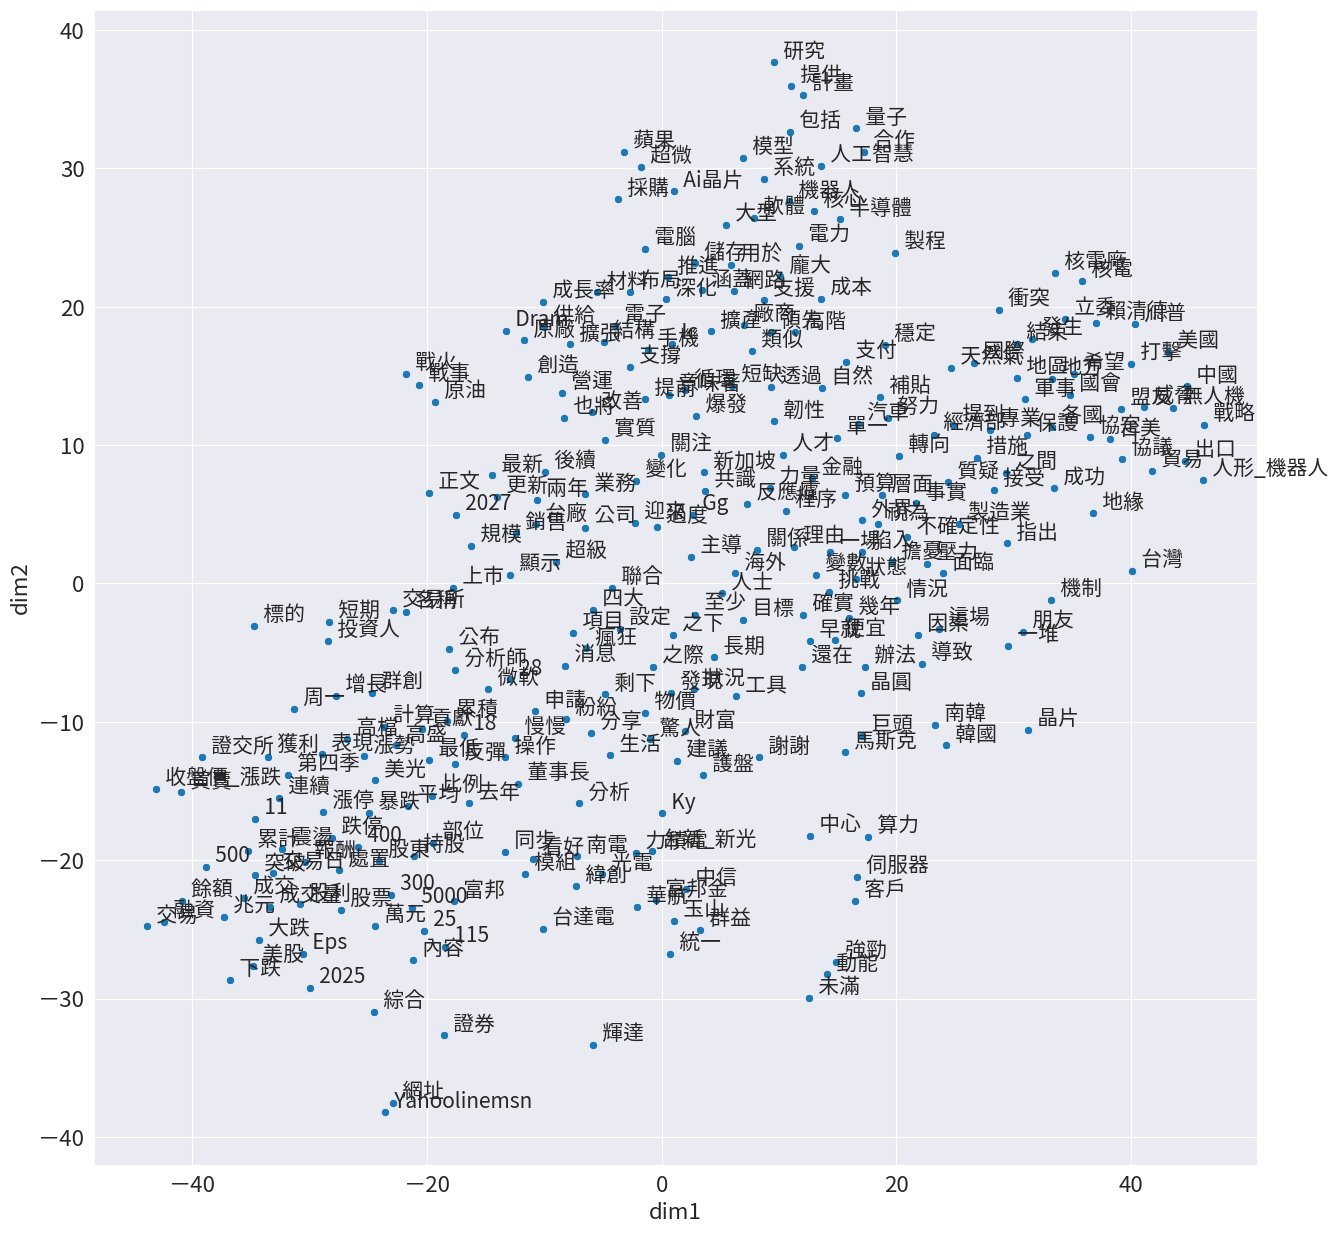

In [ ]:
plotScatter(word_df)

##### (4) K-means 分群 3D 散狀圖

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 46.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959514 sha256=fd290f954bcc73e8809be83a43e710cb132c15a3e4d7265a7b456a884ebf2b7e
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
# 分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result


In [ ]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

##### ＃RQ1：PTT 使用者討論 NVIDIA 與 AI 晶片熱潮時，主要形成哪些主題？

1. 「輝達」周邊詞包含 NVIDIA、蘋果、微軟、超微、執行長、受惠等詞，表示 PTT 使用者對輝達的討論不僅集中於品牌本身，也延伸到科技巨頭競爭、企業領袖形象與 AI 產業受惠等面向。

In [ ]:
# 檢查最相關的字
w2v_model.wv.most_similar('輝達',topn=10)

[('超微', 0.878049910068512),
 ('蘋果', 0.8630663156509399),
 ('黃仁勳', 0.8455472588539124),
 ('執行長', 0.8454170823097229),
 ('財報', 0.8248995542526245),
 ('GPU', 0.7348389625549316),
 ('AMD', 0.6431336998939514),
 ('推出', 0.6420163512229919),
 ('最新', 0.6097162365913391),
 ('AI晶片', 0.6036336421966553)]

2. 「晶片」的相似詞集中在製造、生產、技術、晶圓、製程與高階等詞，顯示 AI 晶片熱潮在 PTT 中主要被放在半導體製造與先進製程的脈絡下討論，並與 AI 模型運算及硬體需求產生連結。

In [ ]:
w2v_model.wv.most_similar('晶片',topn=10)

[('生產', 0.8406535387039185),
 ('AI晶片', 0.8289837837219238),
 ('製造', 0.8030734062194824),
 ('製造商', 0.7902137637138367),
 ('技術', 0.783774197101593),
 ('高階', 0.7407500147819519),
 ('採購', 0.7209392189979553),
 ('晶圓廠', 0.7021447420120239),
 ('採用', 0.7006304860115051),
 ('製程', 0.6876797080039978)]

In [ ]:
w2v_model.wv.most_similar('台積電',topn=10)

[('股票', 0.7515299916267395),
 ('持有', 0.6794772148132324),
 ('2330', 0.6660494804382324),
 ('薪水', 0.6636790037155151),
 ('2000', 0.6566593647003174),
 ('ADR', 0.6388204097747803),
 ('0050', 0.6360666155815125),
 ('鴻海', 0.6352793574333191),
 ('一張', 0.6300960779190063),
 ('股東', 0.5996749997138977)]

In [ ]:
w2v_model.wv.most_similar('AI伺服器',topn=10)

[('伺服器', 0.9324889779090881),
 ('強勁', 0.8856739401817322),
 ('題材', 0.8707713484764099),
 ('客戶', 0.8638677000999451),
 ('支撐', 0.8553849458694458),
 ('趨勢', 0.8451727032661438),
 ('HBM', 0.8386783003807068),
 ('大廠', 0.8344637155532837),
 ('電子', 0.8307622075080872),
 ('動能', 0.8211435675621033)]

In [ ]:
w2v_model.wv.most_similar(['鴻海','輝達'],topn=10)

[('財報', 0.8109259605407715),
 ('美元', 0.7692437767982483),
 ('股價', 0.7330029606819153),
 ('高達', 0.7262571454048157),
 ('蘋果', 0.7220772504806519),
 ('高點', 0.7097087502479553),
 ('加碼', 0.7009618282318115),
 ('瘋狂', 0.7005116939544678),
 ('來到', 0.6998101472854614),
 ('超過', 0.6816518306732178)]

In [ ]:
# 比較字詞間，誰最不相關
# 台灣供應鏈主題：檢查 NVIDIA 與台灣供應鏈公司是否處於相近語境，若某個詞被判為最不相似，可能代表它在 PTT 中被討論的角度不同。
w2v_model.wv.doesnt_match([
    "台積電",
    "鴻海",
    "廣達",
    "緯創",
    "輝達"
])

'輝達'

##### ＃額外探討：NVIDIA與投資的情緒關聯

1. 當「輝達」與「股票」共同進入投資語境時
   *   結果：財報、部位、加碼、股價、持股、槓桿、高點、跌破
   *   代表PTT 對輝達的股票討論偏熱，但不是盲目樂觀，而是同時伴隨高波動與風險意識。

2. 排除晶片技術後的輝達投資語境
   *   結果：持股、部位、跌破、加碼、槓桿、目標價、大跌、500、千點、短線
   *   排除晶片技術語境後，輝達的投資討論更明顯集中在持股、部位、加碼、目標價、短線、跌破與大跌等市場操作詞彙。
   *   代表討論轉向投資部位管理、短線交易、目標價判斷與股價下跌風險。

3. 輝達的看多／受惠語境
   *   結果：博通、伺服器、GPU、散熱、預期、規模、財報、TPU、客戶、大幅
   *   PTT 對輝達受惠的想像主要來自 AI 伺服器、GPU 需求、散熱供應鏈、客戶需求與財報表現。
   *   這也表示使用者不只討論輝達本身，而是會把 AI 晶片熱潮延伸到上下游供應鏈與競爭技術。

4. 排除晶片技術後的泡沫語境
   *   結果：預期、業績、幅度、大幅、出貨、營收、呈現、預估、亮眼、華爾街
   *   本次 Word2Vec 模型未能分析「泡沫」語境，原因是「泡沫」不在模型詞庫中。
   *   然而，在「輝達＋股票」及「輝達＋股票－晶片」結果中，已出現跌破、大跌、高點、槓桿、短線等風險詞，表示 PTT 的看壞或風險討論可能不是集中使用「泡沫」一詞，而是以股價波動與短線操作風險的方式呈現。

In [ ]:
investment_queries = [
    {
        "name": "輝達的股票投資語境",
        "positive": ["輝達", "股票"],
        "negative": []
    },
    {
        "name": "排除晶片技術後的輝達投資語境",
        "positive": ["輝達", "股票"],
        "negative": ["晶片"]
    },
    {
        "name": "輝達的看多／受惠語境",
        "positive": ["輝達", "受惠"],
        "negative": []
    },
    {
        "name": "排除晶片技術後的看多語境",
        "positive": ["輝達", "受惠"],
        "negative": ["晶片"]
    },
    {
        "name": "輝達的泡沫／風險語境",
        "positive": ["輝達", "泡沫"],
        "negative": []
    },
    {
        "name": "排除晶片技術後的泡沫語境",
        "positive": ["輝達", "泡沫"],
        "negative": ["晶片"]
    }
]

for q in investment_queries:
    pos = q["positive"]
    neg = q["negative"]

    valid_pos = all(w in w2v_model.wv.key_to_index for w in pos)
    valid_neg = all(w in w2v_model.wv.key_to_index for w in neg)

    print("\n==============================")
    print(q["name"])
    print("positive =", pos, "negative =", neg)

    if valid_pos and valid_neg:
        result = w2v_model.wv.most_similar(
            positive=pos,
            negative=neg,
            topn=10
        )
        for word, score in result:
            print(word, round(score, 4))
    else:
        missing = [w for w in pos + neg if w not in w2v_model.wv.key_to_index]
        print("以下詞不在 Word2Vec 詞庫中：", missing)


輝達的股票投資語境
positive = ['輝達', '股票'] negative = []
財報 0.8108
部位 0.7682
加碼 0.7438
瘋狂 0.7394
股價 0.7208
持股 0.7097
槓桿 0.7042
美元 0.7035
高點 0.6858
跌破 0.6768

排除晶片技術後的輝達投資語境
positive = ['輝達', '股票'] negative = ['晶片']
持股 0.8977
部位 0.8799
跌破 0.8704
加碼 0.8605
槓桿 0.8594
目標價 0.8348
大跌 0.8327
500 0.8283
千點 0.8278
短線 0.8275

輝達的看多／受惠語境
positive = ['輝達', '受惠'] negative = []
博通 0.8433
伺服器 0.8319
GPU 0.821
散熱 0.8167
預期 0.795
規模 0.7948
財報 0.7787
TPU 0.7722
客戶 0.7647
大幅 0.7617

排除晶片技術後的看多語境
positive = ['輝達', '受惠'] negative = ['晶片']
預期 0.8528
業績 0.8493
幅度 0.8408
大幅 0.8394
出貨 0.8325
營收 0.8157
呈現 0.8137
預估 0.8007
亮眼 0.7879
華爾街 0.787

輝達的泡沫／風險語境
positive = ['輝達', '泡沫'] negative = []
以下詞不在 Word2Vec 詞庫中： ['泡沫']

排除晶片技術後的泡沫語境
positive = ['輝達', '泡沫'] negative = ['晶片']
以下詞不在 Word2Vec 詞庫中： ['泡沫']


### 2.上課範例：使用別人訓練好的word2vec模型

使用臺北醫學大學做的預訓練 Word2Vec 模型當範例，需將模型檔下載下來   
（來源：http://nlp.tmu.edu.tw/word2vec/index.html ）

In [ ]:
model_tmu = KeyedVectors.load_word2vec_format('./tmunlp_1.6B_WB_50dim_2020v1.bin', unicode_errors='ignore', binary=True)

In [ ]:
model_tmu.most_similar('癌症',topn=10)

In [ ]:
model_tmu.most_similar('咳嗽',topn=10)

In [ ]:
model_tmu.most_similar(positive=['疾病','咳嗽'],topn=10)

## Transformers Embeddings

### 1.Sentence-Transformer 套件   
參考資料：https://www.sbert.net/index.html

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstalling typer-0.9.4:
      Successfully uninstalled typer-0.9.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.
spacy 3.7.2 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.


In [ ]:
from sentence_transformers import SentenceTransformer, models, util

/tmp/ipykernel_1763/593637398.py:1: DeprecationWarning:

Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.



### 2.課堂範例

#### (1) 小模型 以BERT為範例

註：在挑選語言模型時需確認其訓練資料的來源，因為不一定都具備**跨語言**的能力。   
接下來將以針對英文、中文以及多語言進行訓練的三種BERT模型做範例。

In [ ]:
# 英文 bert-base-uncased
bert_en = SentenceTransformer('google-bert/bert-base-uncased')

bert_en.tokenizer.add_special_tokens({'pad_token': '[PAD]'}) #句子不夠長時可以透過pad_token去補滿長度

In [ ]:
bert_en.get_max_seq_length() #最長可以接受多長的長度

In [ ]:
example_text = "This framework generates embeddings for each input sentence"
example_embeddings = bert_en.encode(example_text)

print(example_embeddings.shape)
print("=======================")
print(example_embeddings)

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence",
    "The quick brown fox jumps over the lazy dog.",
    "The speedy black dog leaps across the cat."
]

# 使用 encode() 對資料做embedding
embeddings_en = bert_en.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_en, embeddings_en)

# 印出句子間的cosine similarity分數
result = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        result.append([sentences[i], sentences[j], cosine_scores[i][j].item()])

result_df = pd.DataFrame(result, columns=["sentence1", "sentence2", "score"])
result_df.sort_values("score", ascending = False)

因為後續在查看結果時會一直使用到此程式碼，所以包成function以便之後使用。

In [ ]:
# 回傳cosine similarity分數
def get_result_df(sentences, cosine_scores):

  result = []
  for i in range(len(sentences)):
      for j in range(i+1, len(sentences)):
          result.append([sentences[i], sentences[j], cosine_scores[i][j].item()])

  result_df = pd.DataFrame(result, columns=["sentence1", "sentence2", "score"])
  result_df = result_df.sort_values("score", ascending = False)

  return result_df

中文 bert-base-chinese

In [ ]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

In [ ]:
# 示範句子
sentences = [
    "今天天氣很好。",
    "今天是個晴空萬里的好天氣。",
    "我晚上想去公園散步。"
]

# 使用 encode() 對資料做embedding
embeddings_ch = bert_ch.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_ch, embeddings_ch)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

多語言 bert-base-multilingual-cased

In [ ]:
# 多語言 bert-base-multilingual-cased
bert_multi = SentenceTransformer('google-bert/bert-base-multilingual-cased')

bert_multi.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。"
]

# 使用 encode() 對資料做embedding
embeddings_multi = bert_multi.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_multi, embeddings_multi)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

#### (2) 大模型範例

In [ ]:
!pip install tiktoken
!pip install utils

##### [1] API based

###### [1-1] OpenAI

**注意**   
Openai的API會要求綁定信用卡後才能使用，且綁定信用卡後會刷5美金的初始費用。   
請自行斟酌是否要嘗試這一部分的程式碼！

In [ ]:
!pip install --upgrade openai

In [ ]:
# from openai import OpenAI
import openai
import os

openai.api_key = '你的API_KEY' # 設置API_KEY

def get_embedding_openai(text, model):
   #text = text.replace("\n", " ")
   return openai.embeddings.create(input = [text], model=model).data[0].embedding

In [ ]:
embedding_model = "text-embedding-3-small"
embedding_encoding = "cl100k_base"
max_tokens = 8000  # the maximum for text-embedding-3-small is 8191

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。",
    "速い茶色のキツネが怠惰な犬を飛び越える"
]

# 取得每一句的embedding
embeddings_openai = [get_embedding_openai(text, model=embedding_model) for text in sentences]

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_openai, embeddings_openai)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

###### [1-2] Cohere

In [ ]:
!pip install cohere

In [ ]:
import cohere

co = cohere.Client("3j0KoPQZJR7Sg74r1zJwDm0Om0qTj8BKMZ4ouU6b") # 設置API_KEY

embedding_model = "embed-multilingual-v3.0"

def get_embedding_cohere(text, model):
   #text = text.replace("\n", " ")
   return co.embed(texts=[text], model=model, input_type="classification").embeddings[0]

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。",
    "速い茶色のキツネが怠惰な犬を飛び越える"
]

# 使用 encode() 對資料做embedding
embeddings_cohere = [get_embedding_cohere(text, model=embedding_model) for text in sentences]

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_cohere, embeddings_cohere)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

##### [2] Open Source LLM

In [ ]:
from huggingface_hub import notebook_login
notebook_login() # 模型需要權限時，去申請後輸入Hugging Face 帳號的Token

###### [2-1] Microsoft - Phi 4

In [ ]:
# model_phi3 = SentenceTransformer('microsoft/Phi-3.5-mini-instruct')
model_phi4 = SentenceTransformer('microsoft/Phi-4-mini-instruct')

model_phi4.tokenizer.pad_token = model_phi4.tokenizer.eos_token

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence",
    "The quick brown fox jumps over the lazy dog.",
    "The speedy black dog leaps across the cat."
]

# 使用 encode() 對資料做embedding
embeddings_phi4 = model_phi4.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_phi4, embeddings_phi4)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

這裡需注意一下，上述的開源LLM基本上是decoder-only，它們主要的任務目標是要生成下一個字，並不是主要拿來做sentence embedding的。   
有興趣的同學可以參考[embedding相關任務的leaderboard](https://huggingface.co/spaces/mteb/leaderboard)，試試上面的模型。

### 3.Embedding 做 NLP 任務

#### (1) 課堂練習：相似文件分析
使用 google-bert/bert-base-multilingual-cased

In [ ]:
df_similar = origin_data[['system_id','artTitle', 'artContent']]
df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

/tmp/ipykernel_1763/852741673.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,system_id,artTitle,artContent
0,1,台股大盤漲基層無感雞腿便當130 帳單,聯合台股大盤漲基層無感雞腿便當帳單漲有感聯合報葉德正新北即時報導台股屢創新高但對不少基層民眾...
1,2,問卦 美國版的我們這一家這樣行嗎,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...
2,3,問卦 韌性是可以多萬用 不膩嗎,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...
3,4,台積電高雄廠2奈米量產市府 高雄躍升全,媒體來源自由時報葛祐豪完整標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程關鍵聚落完整...
4,5,RE 台股大盤漲基層無感雞腿便當130 帳單,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...


In [ ]:
bert_ch = SentenceTransformer('google-bert/bert-base-multilingual-cased', device='cpu')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

0

取得整個文集的 embeddings

In [ ]:
corpus_embeddings = bert_ch.encode(
    df_similar['artContent'].to_list(),
    convert_to_tensor=True,
    batch_size=32
)

In [ ]:
query_num = 6 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5 #前五篇相似的文章


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: 台積電高雄2奈米廠正式量產新增2匝道及

 資料集中前五相似的文章:
台積電高雄2奈米廠正式量產新增2匝道及 (Score: 1.0000)
台積電高雄廠2奈米量產市府 高雄躍升全 (Score: 0.9821)
陳其邁曬施政成績 高雄失業率六都最低 (Score: 0.9646)
無人機訂單開水龍頭狂灌 工具機大廠 (Score: 0.9474)
馬斯克開挖神山牆角 巨型晶圓廠TERAFAB (Score: 0.9457)






In [ ]:
query_num = 50

top_k = 5

query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: RE 問卦 40歲台男買一堆台積電股票不空虛嗎

 資料集中前五相似的文章:
RE 問卦 40歲台男買一堆台積電股票不空虛嗎 (Score: 1.0000)
問卦 8年級中後段是不是很爽 (Score: 0.9281)
RE 問卦 男人找對象會降級 女生寧可單身 (Score: 0.9263)
RE 心得 台指期 8個月從740萬滾到3 85億 (Score: 0.9218)
RE 標的 00679B00687B元大 國泰美債20年 (Score: 0.9217)






## ＃RQ2：Gossiping 與 Stock 對 NVIDIA 的討論焦點是否不同？(第七周文件分類延伸)

1. 本次分析共使用 1255 篇文章，其中 Gossiping 比 Stock 多一些
2. 把文章內容轉成BERT的語意向量，再讓模型去判斷這篇文章是 Gossiping 還是 Stock【結果準確率達到 90.19%】

3. 結果：
   *   Gossiping 預測準確度90%以上，代表文章語境很明顯，通常可能包含「問卦」、「爆卦」、新聞轉貼、社會情緒、人物評論、台灣之光或酸民式語氣。
   *   Stock 稍微低於 Gossiping，可能是因為 Stock 板也常轉貼新聞、討論台積電或國際科技事件，因此部分文章內容會和 Gossiping 有重疊。

4. 分析：
   *   兩個看板雖然都在談 NVIDIA、AI 晶片或台積電，但實際上討論語境很不一樣。
   *   Gossiping 比較像是在討論新聞事件、社會感受或人物形象
   *   Stock 則比較明顯是在談股價、財報、產業鏈與投資判斷。
   *   模型誤判的文章很有意思，例如有些 Gossiping 文章因為大量出現美股、台積電 ADR、股市下跌等詞，所以被判成 Stock，這代表部分八卦板文章雖然發在大眾看板，但內容其實已經接近投資討論。

In [ ]:
# ==========================================
# RQ2：Gossiping 與 Stock 對 NVIDIA 的討論焦點是否不同？
# 方法：BERT Embeddings + Logistic Regression 看板分類
# 資料層級：文章層級
# 統一資料名稱：data
# ==========================================

!pip install -U sentence-transformers

import pandas as pd
import numpy as np
import re

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

data = pd.read_csv("./S3-2.csv", encoding="utf-8-sig")

# 2. 過濾空值
# RQ2 需要文章標題、文章內容、看板類別

data = data.dropna(subset=["artTitle", "artContent", "artCatagory"]).copy()

# 3. 轉成字串，避免後面清理文字時出錯

data["artTitle"] = data["artTitle"].astype(str)
data["artContent"] = data["artContent"].astype(str)

# 4. 移除網址

data["artTitle"] = data["artTitle"].apply(
    lambda x: re.sub(r"(http|https)://\S+", "", x)
)

data["artContent"] = data["artContent"].apply(
    lambda x: re.sub(r"(http|https)://\S+", "", x)
)

# 5. 保留中文、英文、數字
# 注意：不能只保留中文，因為 AI、NVIDIA、NVDA、GPU、GB200 都很重要
# 其他符號改成空白，避免文字全部黏在一起

data["artTitle"] = data["artTitle"].apply(
    lambda x: re.sub(r"[^\u4e00-\u9fffA-Za-z0-9]+", " ", x).strip()
)

data["artContent"] = data["artContent"].apply(
    lambda x: re.sub(r"[^\u4e00-\u9fffA-Za-z0-9]+", " ", x).strip()
)

# 6. 統一英文大小寫
# 例如 ai、Ai、AI 都變成 AI
# nvidia、Nvidia、NVIDIA 都變成 NVIDIA

data["artTitle"] = data["artTitle"].str.upper()
data["artContent"] = data["artContent"].str.upper()

# 7. 統一重要詞彙
# 讓 NVDA、輝達、NVDIA 都盡量統一成 NVIDIA
# 這樣模型和後續分析比較穩定

replace_dict = {
    "NVDA": "NVIDIA",
    "NVDIA": "NVIDIA",
    "輝達": "NVIDIA",
    "老黃": "黃仁勳",
    "JENSEN": "黃仁勳",
    "JENSENHUANG": "黃仁勳",
    "TSMC": "台積電",
    "CO WOS": "COWOS",
    "COWOS": "COWOS",
    "AI SERVER": "AI伺服器"
}

for old, new in replace_dict.items():
    data["artTitle"] = data["artTitle"].str.replace(old, new, regex=False)
    data["artContent"] = data["artContent"].str.replace(old, new, regex=False)

# 8. 移除停用字
stop_words = [
    "連結",
    "轉載",
    "備註",
    "請放違者",
    "網站",
    "刪除",
    "新聞",
    "這項",
    "錯誤",
    "記者",
    "比較",
    "優於",
    "有人",
    "上班",
    "補充",
    "時間",
    "張券",
    "協助",
    "署名",
    "發布",
    "第一",
    "原本",
    "內文",
    "仟元",
    "大學",
    "處於",
    "近年",
    "代表",
    "做出",
    "達成",
    "包含",
    "詐騙",
    "八卦"
]

for word in stop_words:
    data["artTitle"] = data["artTitle"].str.replace(word, "", regex=False)
    data["artContent"] = data["artContent"].str.replace(word, "", regex=False)

# 9. 移除多餘空白

data["artTitle"] = data["artTitle"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

data["artContent"] = data["artContent"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

# 10. 建立 content 欄位
# RQ2 要用 content 轉 embeddings

data["content"] = data["artTitle"] + " " + data["artContent"]

# 11. 計算文章長度，排除太短文章

data["content_length"] = data["content"].str.len()
data = data[data["content_length"] >= 20].copy()

# 12. Gossiping 與 Stock

data = data[data["artCatagory"].isin(["Gossiping", "Stock"])].copy()

print("看板資料量：")
print(data["artCatagory"].value_counts())

print("資料筆數與欄位：")
print(data.shape)
print(data.columns)

display(data[["system_id", "artCatagory", "artTitle", "content_length", "content"]].head())

# 13. 載入 BERT Embedding 模型
# 使用 multilingual-cased 是因為資料包含中文、英文

bert_model = SentenceTransformer(
    "google-bert/bert-base-multilingual-cased",
    device="cpu"
)

bert_model.tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# 14. 將文章 content 轉成 embeddings
# 每一篇文章會變成一個 768 維的向量

embeddings = bert_model.encode(
    data["content"].tolist(),
    batch_size=16,
    show_progress_bar=True
)

print("Embeddings shape：", embeddings.shape)

# 15. 建立 X 與 y
# X：文章的 BERT 語意向量
# y：文章所屬看板 Gossiping / Stock

X = pd.DataFrame(embeddings, index=data.index)
y = data["artCatagory"]

# 16. 切分訓練集與測試集

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=777,
    stratify=y
)

print("訓練集資料量：", X_train.shape)
print("測試集資料量：", X_test.shape)

print("訓練集看板分布：")
print(y_train.value_counts())

print("測試集看板分布：")
print(y_test.value_counts())

# 17. 訓練 Logistic Regression 分類器
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# 18. 預測測試集

y_pred = clf.predict(X_test)

# 19. 評估分類結果
# 如果 Accuracy / F1-score 高，代表兩個看板的討論語境有明顯差異

print("Accuracy：", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

print("Confusion Matrix：")
print(confusion_matrix(y_test, y_pred))

# 20. 整理預測結果
# 可以用來看哪些文章被判對，哪些文章被誤判

rq2_result = data.loc[y_test.index].copy()

rq2_result["true_board"] = y_test
rq2_result["pred_board"] = y_pred
rq2_result["is_correct"] = rq2_result["true_board"] == rq2_result["pred_board"]

display(
    rq2_result[[
        "system_id",
        "artTitle",
        "true_board",
        "pred_board",
        "is_correct",
        "content"
    ]].head(10)
)

看板資料量：
artCatagory
Gossiping    720
Stock        535
Name: count, dtype: int64
資料筆數與欄位：
(1255, 10)
Index(['system_id', 'content', 'artTitle', 'artContent', 'artUrl',
       'artCatagory', 'artDate', 'artPoster', 'embeddings', 'content_length'],
      dtype='object')


,system_id,artCatagory,artTitle,content_length,content
0,1,Gossiping,台股大盤漲基層無感雞腿便當130 帳單,734,台股大盤漲基層無感雞腿便當130 帳單 聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感...
1,2,Gossiping,問卦 美國版的我們這一家這樣行嗎,913,問卦 美國版的我們這一家這樣行嗎 美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美...
2,3,Gossiping,問卦 韌性是可以多萬用 不膩嗎,125,問卦 韌性是可以多萬用 不膩嗎 干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台...
3,4,Gossiping,台積電高雄廠2奈米量產市府 高雄躍升全,934,台積電高雄廠2奈米量產市府 高雄躍升全 1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台...
4,5,Gossiping,RE 台股大盤漲基層無感雞腿便當130 帳單,145,RE 台股大盤漲基層無感雞腿便當130 帳單 不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings shape： (1255, 768)
訓練集資料量： (878, 768)
測試集資料量： (377, 768)
訓練集看板分布：
artCatagory
Gossiping    504
Stock        374
Name: count, dtype: int64
測試集看板分布：
artCatagory
Gossiping    216
Stock        161
Name: count, dtype: int64
Accuracy： 0.9018567639257294

              precision    recall  f1-score   support

   Gossiping       0.92      0.91      0.91       216
       Stock       0.88      0.89      0.89       161

    accuracy                           0.90       377
   macro avg       0.90      0.90      0.90       377
weighted avg       0.90      0.90      0.90       377

Confusion Matrix：
[[196  20]
 [ 17 144]]


,system_id,artTitle,true_board,pred_board,is_correct,content
639,640,問卦 即使世界末日台積電不會跌,Gossiping,Gossiping,True,問卦 即使世界末日台積電不會跌 明明戰火激烈 股市暴跌 台積電仍然有一群大人小孩 一路買上來...
456,457,RE 問卦 四戰全輸會發生什麼事,Gossiping,Gossiping,True,RE 問卦 四戰全輸會發生什麼事 實際是世界冠軍變世界笑柄 但是滯台閩南人只喜歡聽好聽話 沒...
248,249,RE 問卦 台積電文化,Gossiping,Gossiping,True,RE 問卦 台積電文化 想像一下 你菜的時候被學長電趴在地上 等到你變學長的時候你可能對學弟...
30,31,問卦 業過年也有加倍獎金嗎,Gossiping,Stock,False,問卦 業過年也有加倍獎金嗎 小魯高雄51處辣 過年期間人人滿手現金 領錢又能以紅包名義領大額...
978,979,台積電2026分紅開獎了 年薪輕鬆破3百萬,Stock,Gossiping,False,台積電2026分紅開獎了 年薪輕鬆破3百萬 原文標題 台積電2026分紅開獎了 年薪輕鬆破3...
937,938,閒聊 2026 02 25盤後閒聊,Stock,Stock,True,閒聊 2026 02 25盤後閒聊 台 股 35413 07 712 25 2 05 981...
430,431,RE 爆卦 卡達天然氣生產將中斷一個月,Gossiping,Stock,False,RE 爆卦 卡達天然氣生產將中斷一個月 低 少 TA AI的答案 台灣與卡達之間最重要的長期...
383,384,美股道瓊跌破千點 台積電ADR跌5 黃金,Gossiping,Stock,False,美股道瓊跌破千點 台積電ADR跌5 黃金 請放最後面 違者文章 1 媒體來源 TVBS 2 ...
462,463,問卦 贏日本了哈哈哈,Gossiping,Gossiping,True,問卦 贏日本了哈哈哈 台灣的台積電在先進晶片製程上吊打日本 台灣贏日本了啦哈哈哈哈哈哈
351,352,問卦 台股翻紅 台積電翻紅,Gossiping,Gossiping,True,問卦 台股翻紅 台積電翻紅 美伊戰爭台股似乎不太受影響 韓股與日股這幾天的跌幅都在台股的2倍...


誤判文章數： 37


,system_id,artTitle,true_board,pred_board,content
30,31,問卦 業過年也有加倍獎金嗎,Gossiping,Stock,問卦 業過年也有加倍獎金嗎 小魯高雄51處辣 過年期間人人滿手現金 領錢又能以紅包名義領大額...
978,979,台積電2026分紅開獎了 年薪輕鬆破3百萬,Stock,Gossiping,台積電2026分紅開獎了 年薪輕鬆破3百萬 原文標題 台積電2026分紅開獎了 年薪輕鬆破3...
430,431,RE 爆卦 卡達天然氣生產將中斷一個月,Gossiping,Stock,RE 爆卦 卡達天然氣生產將中斷一個月 低 少 TA AI的答案 台灣與卡達之間最重要的長期...
383,384,美股道瓊跌破千點 台積電ADR跌5 黃金,Gossiping,Stock,美股道瓊跌破千點 台積電ADR跌5 黃金 請放最後面 違者文章 1 媒體來源 TVBS 2 ...
565,566,AITOKEN成NVIDIA徵才一環 黃仁勳警告,Gossiping,Stock,AITOKEN成NVIDIA徵才一環 黃仁勳警告 AI TOKEN成NVIDIA徵才一環 黃...
724,725,台股大盤漲基層無感雞腿便當130 帳單,Stock,Gossiping,台股大盤漲基層無感雞腿便當130 帳單 原文標題 台股大盤漲基層無感 雞腿便當130 帳單漲...
202,203,RE 問卦 AI伺服器在太空散熱的方法,Gossiping,Stock,RE 問卦 AI伺服器在太空散熱的方法 今天黃仁勳財報就說到了 散熱困難 勉強擠了一個例子説...
622,623,代理式AI新武器亮相 HOYABIT發豪語,Gossiping,Stock,代理式AI新武器亮相 HOYABIT發豪語 請放最後面 違者文章 1 媒體來源 ETTODA...
737,738,電網商機千億線纜業利多華榮 大亞等廠,Stock,Gossiping,電網商機千億線纜業利多華榮 大亞等廠 電網商機千億 線纜業利多 華榮 大亞等廠商受惠 202...
37,38,RE 問卦 都沒人好奇台積電在漲什麼嗎,Gossiping,Stock,RE 問卦 都沒人好奇台積電在漲什麼嗎 比如說台積電一年賺30元好了 那合理價是多少呢 30...


已輸出：RQ2_BERT_board_classification_result.csv
已輸出：RQ2_wrong_cases.csv


In [ ]:
#  判斷錯誤的文章內容
wrong_cases = rq2_result[rq2_result["is_correct"] == False]

wrong_cases[[
    "system_id",
    "artTitle",
    "true_board",
    "pred_board",
    "content"
]].head(10)

,system_id,artTitle,true_board,pred_board,content
30,31,問卦 業過年也有加倍獎金嗎,Gossiping,Stock,問卦 業過年也有加倍獎金嗎 小魯高雄51處辣 過年期間人人滿手現金 領錢又能以紅包名義領大額...
978,979,台積電2026分紅開獎了 年薪輕鬆破3百萬,Stock,Gossiping,台積電2026分紅開獎了 年薪輕鬆破3百萬 原文標題 台積電2026分紅開獎了 年薪輕鬆破3...
430,431,RE 爆卦 卡達天然氣生產將中斷一個月,Gossiping,Stock,RE 爆卦 卡達天然氣生產將中斷一個月 低 少 TA AI的答案 台灣與卡達之間最重要的長期...
383,384,美股道瓊跌破千點 台積電ADR跌5 黃金,Gossiping,Stock,美股道瓊跌破千點 台積電ADR跌5 黃金 請放最後面 違者文章 1 媒體來源 TVBS 2 ...
565,566,AITOKEN成NVIDIA徵才一環 黃仁勳警告,Gossiping,Stock,AITOKEN成NVIDIA徵才一環 黃仁勳警告 AI TOKEN成NVIDIA徵才一環 黃...
724,725,台股大盤漲基層無感雞腿便當130 帳單,Stock,Gossiping,台股大盤漲基層無感雞腿便當130 帳單 原文標題 台股大盤漲基層無感 雞腿便當130 帳單漲...
202,203,RE 問卦 AI伺服器在太空散熱的方法,Gossiping,Stock,RE 問卦 AI伺服器在太空散熱的方法 今天黃仁勳財報就說到了 散熱困難 勉強擠了一個例子説...
622,623,代理式AI新武器亮相 HOYABIT發豪語,Gossiping,Stock,代理式AI新武器亮相 HOYABIT發豪語 請放最後面 違者文章 1 媒體來源 ETTODA...
737,738,電網商機千億線纜業利多華榮 大亞等廠,Stock,Gossiping,電網商機千億線纜業利多華榮 大亞等廠 電網商機千億 線纜業利多 華榮 大亞等廠商受惠 202...
37,38,RE 問卦 都沒人好奇台積電在漲什麼嗎,Gossiping,Stock,RE 問卦 都沒人好奇台積電在漲什麼嗎 比如說台積電一年賺30元好了 那合理價是多少呢 30...


## ＃RQ3：PTT 對 NVIDIA / AI 晶片熱潮的投資態度分析

*   利用規則式詞典分類，不另外訓練模型，把投資語境分成「看好」、「觀望」和「看壞／泡沫疑慮」三類，作為初步投資態度分析。

    *   「受惠、創高、成長、訂單、需求」會被歸為看好；「估值、財報、法說、本益比、觀望」會被歸為觀望；「泡沫、追高、套牢、崩、下跌、風險」會被歸為看壞或泡沫疑慮。
    *   程式會逐句掃描這些詞，計算每一句的三類分數，分數最高的類別就是該句的投資態度。
    *   如果都沒有命中，就標成未明確表態。

1. 整體投資態度：偏看好，但仍有風險意識，「看壞／泡沫疑慮」也有將近兩成，代表 PTT 並不是完全一面倒樂觀，仍然存在對追高、泡沫、大跌、套牢、風險的討論。

*   Stock 明顯偏看好，Gossiping 則有更多未明確表態與風險／泡沫疑慮。
    *   整體句子層級中「看好」有 488 筆、占 38.88%
    *   「看壞／泡沫疑慮」有 237 筆、占 18.88%
    *   「觀望」有 138 筆、占 11.00%
    *   另有 392 筆、占 31.24% 為未明確表態。

2. Gossiping 與 Stock 的差異很明顯   
*   Gossiping：大眾討論較分散，未明確表態最多
    *   雖然也會討論台積電、NVIDIA、AI、股市上漲，但很多內容比較像新聞轉貼、問卦、社會感受或情緒討論，不一定會明確表達投資立場。
    *   「看壞／泡沫疑慮」比例也不低，代表大眾看板比較容易出現「買在高點會不會套牢」、「台股是不是太熱」、「追高會不會危險」這類討論。

*   Stock：投資語境非常明確，且明顯偏看好
    *   「看好」比例超過一半，代表在投資社群中，NVIDIA／AI 晶片熱潮主要被解讀為正向題材。
    *   討論通常會連結到受惠、營收、出貨、財報、AI 伺服器、供應鏈等投資判斷。
    *   同時 Stock 的「觀望」比例比 Gossiping 高很多，表示 Stock 使用者不是單純情緒化看多，而是會討論估值、本益比、財報、法說、外資、目標價等更具投資判斷意味的因素。

3. 句子層級：各看板投資態度筆數
*   看好代表句

    *   常出現「AI 帶動」、「GDP 成長」、「台積電創新高」、「三大法人爆買」、「股市漲」等語境。
    *   看好情緒主要來自：AI 熱潮帶動台股,台積電與半導體產業成長, 法人買盤與股價創高, 台灣供應鏈受惠
    *   看好不是單純喊多，而是建立在 AI、台積電、半導體、股市上漲與產業受惠的敘事上。

*   觀望代表句
    *   常見「財報」、「外資」、「合理價」、「觀望」、「預期」、「華爾街」等詞。
    *   使用者雖然關注 NVIDIA 或台積電，但仍會等待更多市場訊號，例如財報結果、外資買賣、股價是否合理、後續是否繼續上漲。
    *   語氣比較像：不是不看好，但要看財報、估值與後續市場反應。


*   看壞代表句
    *   常出現「大跌」、「風險」、「套牢」、「追高」、「高點」、「崩盤」、「跌破」、「AI 泡沫」等語境。
    *   代表 PTT 對 AI 晶片熱潮也有明顯風險意識，尤其是在台積電或 NVIDIA 股價漲高之後，使用者會擔心：
        *   現在追高會不會被套？
        *   AI 題材是不是過熱？
        *   股價是不是已經反映太多？
        *   如果大跌或跌破關鍵價位怎麼辦？

    *   不是完全否定 AI 產業，而是比較擔心「股價已經漲太多」和「投資風險」。

In [ ]:
# ==========================================
# RQ3：PTT 對 NVIDIA / AI 晶片熱潮的投資態度分析
# 方法：規則式投資態度詞典
# 資料層級：
# data     = 文章層級資料
# metaData = 句子層級資料
# 分類類別：看好 / 觀望 / 看壞或泡沫疑慮 / 未明確表態
# ==========================================

import pandas as pd
import re

# ==========================================
# 1. 讀入文章層級資料
# 統一命名為 data
# ==========================================

data = pd.read_csv("./S3-2.csv", encoding="utf-8-sig")

# 過濾必要欄位空值
data = data.dropna(subset=["system_id", "artTitle", "artContent", "artCatagory"]).copy()

# 轉成字串，避免後續處理錯誤
data["artTitle"] = data["artTitle"].astype(str)
data["artContent"] = data["artContent"].astype(str)
data["artCatagory"] = data["artCatagory"].astype(str)

# ==========================================
# 2. 建立句子層級資料 metaData
# RQ3 要分析句子中的投資態度，所以要把 artContent 切成句子
# 注意：這裡保留 system_id、artTitle、artCatagory，後面才能彙整回文章與看板
# ==========================================

metaData = data[[
    "system_id",
    "artTitle",
    "artContent",
    "artCatagory",
    "artUrl",
    "artDate"
]].copy()

# 移除網址
metaData["artContent"] = metaData["artContent"].apply(
    lambda x: re.sub(r"(http|https)://\S+", "", x)
)

metaData["artTitle"] = metaData["artTitle"].apply(
    lambda x: re.sub(r"(http|https)://\S+", "", x)
)

# 文章斷句前處理
metaData["sentence"] = metaData["artContent"].str.replace(r"\n\n", "。", regex=True)
metaData["sentence"] = metaData["sentence"].str.replace(r"\n", "", regex=True)

# 依照常見標點符號切句
metaData["sentence"] = metaData["sentence"].str.split(r"[,，。！!？?；;：:]{1,}")
metaData = metaData.explode("sentence").reset_index(drop=True)

# 保留中文、英文、數字
# 不能只保留中文，因為 AI、NVIDIA、NVDA、GPU、GB200、H100 都是重要詞
# 其他符號改成空白，避免文字黏在一起
metaData["sentence"] = metaData["sentence"].apply(
    lambda x: re.sub(r"[^\u4e00-\u9fffA-Za-z0-9]+", " ", str(x)).strip()
)

# 英文統一大寫
metaData["sentence"] = metaData["sentence"].str.upper()
metaData["artTitle"] = metaData["artTitle"].str.upper()

# 統一重要詞彙
replace_dict = {
    "NVDA": "NVIDIA",
    "NVDIA": "NVIDIA",
    "輝達": "NVIDIA",
    "老黃": "黃仁勳",
    "JENSENHUANG": "黃仁勳",
    "JENSEN": "黃仁勳",
    "TSMC": "台積電",
    "CO WOS": "COWOS",
    "COWOS": "COWOS",
    "AI SERVER": "AI伺服器"
}

for old, new in replace_dict.items():
    metaData["sentence"] = metaData["sentence"].str.replace(old, new, regex=False)
    metaData["artTitle"] = metaData["artTitle"].str.replace(old, new, regex=False)

# 移除空句子
metaData = metaData[metaData["sentence"].str.len() > 0].copy()

# ==========================================
# 3. 設定投資態度詞典
# 看好詞：市場期待、受惠、成長、股價上漲
# 觀望詞：估值、財報、法人態度、股價整理
# 看壞詞：泡沫、過熱、追高、下跌風險
# ==========================================

bullish_words = [
    "看好", "受惠", "噴", "噴出", "創高", "新高", "訂單", "缺貨",
    "成長", "上修", "利多", "多頭", "強勢", "需求", "大單",
    "營收創高", "獲利", "毛利率提升", "股價上漲", "長線看好",
    "利潤", "成長動能", "爆發", "大漲", "續強", "上漲",
    "題材", "加持", "支撐", "買盤", "法人看好", "上攻",
    "帶動", "成長性", "前景", "樂觀", "強勁", "旺", "熱潮",
    "AI熱潮", "供應鏈受惠"
]

neutral_words = [
    "觀望", "估值", "本益比", "財報", "法說", "等待", "回檔",
    "目標價", "法人", "外資", "投信", "盤整", "震盪", "整理",
    "合理價", "已反映", "再觀察", "消息", "預期", "估計",
    "不確定", "等待財報", "等待法說", "市場觀望", "保守",
    "持平", "中性", "區間", "整理格局", "尚待觀察"
]

bearish_words = [
    "泡沫", "過熱", "追高", "套", "套牢", "崩", "下修", "庫存",
    "利空", "風險", "修正", "殺", "跌", "暴跌", "高估",
    "估值過高", "不如預期", "出貨延遲", "需求下滑", "財報不佳",
    "崩盤", "大跌", "賣壓", "獲利了結", "修正壓力", "題材退燒",
    "漲多", "過度樂觀", "看壞", "看空", "轉弱", "跌破",
    "下跌", "殺盤", "利多出盡", "風險升高"
]

# ==========================================
# 4. 建立分類函式
# 每一句計算三種分數：
# bullish_score = 看好分數
# neutral_score = 觀望分數
# bearish_score = 看壞 / 泡沫疑慮分數
# ==========================================

def get_bullish_score(text):
    text = str(text)
    return sum(1 for w in bullish_words if w in text)

def get_neutral_score(text):
    text = str(text)
    return sum(1 for w in neutral_words if w in text)

def get_bearish_score(text):
    text = str(text)
    return sum(1 for w in bearish_words if w in text)

def classify_investment_stance(text):
    text = str(text)

    bullish_score = get_bullish_score(text)
    neutral_score = get_neutral_score(text)
    bearish_score = get_bearish_score(text)

    scores = {
        "看好": bullish_score,
        "觀望": neutral_score,
        "看壞／泡沫疑慮": bearish_score
    }

    max_label = max(scores, key=scores.get)

    if scores[max_label] == 0:
        return "未明確表態"
    else:
        return max_label

# ==========================================
# 5. 句子層級分析
# 對 metaData 每一句 sentence 判斷投資態度
# ==========================================

metaData["bullish_score"] = metaData["sentence"].apply(get_bullish_score)
metaData["neutral_score"] = metaData["sentence"].apply(get_neutral_score)
metaData["bearish_score"] = metaData["sentence"].apply(get_bearish_score)
metaData["investment_stance"] = metaData["sentence"].apply(classify_investment_stance)

# ==========================================
# 6. 句子層級：整體投資態度分布
# ==========================================

sentence_stance_summary = metaData["investment_stance"].value_counts().reset_index()
sentence_stance_summary.columns = ["investment_stance", "count"]
sentence_stance_summary["ratio"] = sentence_stance_summary["count"] / sentence_stance_summary["count"].sum()

print("句子層級：整體投資態度分布")
display(sentence_stance_summary)

# ==========================================
# 7. 句子層級：排除未明確表態
# 這樣比較能看出真正有投資語氣的句子偏向哪一類
# ==========================================

metaData_clear = metaData[metaData["investment_stance"] != "未明確表態"].copy()

clear_stance_summary = metaData_clear["investment_stance"].value_counts().reset_index()
clear_stance_summary.columns = ["investment_stance", "count"]
clear_stance_summary["ratio"] = clear_stance_summary["count"] / clear_stance_summary["count"].sum()

print("句子層級：排除未明確表態後的投資態度分布")
display(clear_stance_summary)

# ==========================================
# 8. 句子層級：比較 Gossiping 與 Stock
# normalize='index' 代表每個看板各自加總為 100%
# ==========================================

sentence_board_stance_ratio = pd.crosstab(
    metaData["artCatagory"],
    metaData["investment_stance"],
    normalize="index"
)

sentence_board_stance_count = pd.crosstab(
    metaData["artCatagory"],
    metaData["investment_stance"]
)

print("句子層級：各看板投資態度比例")
display(sentence_board_stance_ratio)

print("句子層級：各看板投資態度筆數")
display(sentence_board_stance_count)

# ==========================================
# 9. 查看各類投資態度代表句
# 這些可以放在報告中當作質化解釋
# ==========================================

print("看好代表句")
display(
    metaData_clear[
        metaData_clear["investment_stance"] == "看好"
    ][[
        "system_id", "artCatagory", "artTitle", "sentence",
        "bullish_score", "investment_stance"
    ]].head(20)
)

print("觀望代表句")
display(
    metaData_clear[
        metaData_clear["investment_stance"] == "觀望"
    ][[
        "system_id", "artCatagory", "artTitle", "sentence",
        "neutral_score", "investment_stance"
    ]].head(20)
)

print("看壞／泡沫疑慮代表句")
display(
    metaData_clear[
        metaData_clear["investment_stance"] == "看壞／泡沫疑慮"
    ][[
        "system_id", "artCatagory", "artTitle", "sentence",
        "bearish_score", "investment_stance"
    ]].head(20)
)

# ==========================================
# 10. 文章層級分析
# 因為 metaData 是句子層級，所以用 system_id 彙整回文章層級
# 每篇文章加總所有句子的看好 / 觀望 / 看壞分數
# ==========================================

article_stance_score = metaData.groupby(["system_id", "artCatagory"]).agg(
    artTitle=("artTitle", "first"),
    bullish_score=("bullish_score", "sum"),
    neutral_score=("neutral_score", "sum"),
    bearish_score=("bearish_score", "sum"),
    sentence_count=("sentence", "count")
).reset_index()

# ==========================================
# 11. 判斷每篇文章整體投資態度
# 哪一種分數最高，就視為該文章主要投資態度
# 如果三種分數都是 0，就是未明確表態
# ==========================================

def classify_article_stance(row):
    scores = {
        "看好": row["bullish_score"],
        "觀望": row["neutral_score"],
        "看壞／泡沫疑慮": row["bearish_score"]
    }

    max_label = max(scores, key=scores.get)

    if scores[max_label] == 0:
        return "未明確表態"
    else:
        return max_label

article_stance_score["article_stance"] = article_stance_score.apply(
    classify_article_stance,
    axis=1
)

# ==========================================
# 12. 文章層級：整體投資態度分布
# ==========================================

article_stance_summary = article_stance_score["article_stance"].value_counts().reset_index()
article_stance_summary.columns = ["article_stance", "count"]
article_stance_summary["ratio"] = article_stance_summary["count"] / article_stance_summary["count"].sum()

print("文章層級：整體投資態度分布")
display(article_stance_summary)

# ==========================================
# 13. 文章層級：比較 Gossiping 與 Stock
# ==========================================

article_board_stance_ratio = pd.crosstab(
    article_stance_score["artCatagory"],
    article_stance_score["article_stance"],
    normalize="index"
)

article_board_stance_count = pd.crosstab(
    article_stance_score["artCatagory"],
    article_stance_score["article_stance"]
)

print("文章層級：各看板投資態度比例")
display(article_board_stance_ratio)

print("文章層級：各看板投資態度筆數")
display(article_board_stance_count)

# ==========================================
# 14. 查看文章層級結果
# ==========================================

display(
    article_stance_score[[
        "system_id",
        "artCatagory",
        "artTitle",
        "bullish_score",
        "neutral_score",
        "bearish_score",
        "sentence_count",
        "article_stance"
    ]].head(20)
)

句子層級：整體投資態度分布


,investment_stance,count,ratio
0,看好,488,0.388845
1,未明確表態,392,0.312351
2,看壞／泡沫疑慮,237,0.188845
3,觀望,138,0.109960


句子層級：排除未明確表態後的投資態度分布


,investment_stance,count,ratio
0,看好,488,0.565469
1,看壞／泡沫疑慮,237,0.274623
2,觀望,138,0.159907


句子層級：各看板投資態度比例


...

article_stance,未明確表態,看壞／泡沫疑慮,看好,觀望
artCatagory,,,,
Gossiping,0.490278,0.198611,0.252778,0.058333
Stock,0.072897,0.175701,0.571963,0.179439


文章層級：各看板投資態度筆數


article_stance,未明確表態,看壞／泡沫疑慮,看好,觀望
artCatagory,,,,
Gossiping,353,143,182,42
Stock,39,94,306,96


,system_id,artCatagory,artTitle,bullish_score,neutral_score,bearish_score,sentence_count,article_stance
0,1,Gossiping,台股大盤漲基層無感雞腿便當130 帳單,5,0,0,1,看好
1,2,Gossiping,問卦 美國版的我們這一家這樣行嗎,1,0,0,1,看好
2,3,Gossiping,問卦 韌性是可以多萬用 不膩嗎,0,0,0,1,未明確表態
3,4,Gossiping,台積電高雄廠2奈米量產市府 高雄躍升全,2,1,0,1,看好
4,5,Gossiping,RE 台股大盤漲基層無感雞腿便當130 帳單,0,0,1,1,看壞／泡沫疑慮
5,6,Gossiping,RE 問卦 經濟學人 台灣應思考開戰後美不出兵應,0,0,0,1,未明確表態
6,7,Gossiping,台積電高雄2奈米廠正式量產新增2匝道及,1,0,0,1,看好
7,8,Gossiping,問卦 2025台灣有完成什麼大事嗎,1,0,0,1,看好
8,9,Gossiping,RE 新規必看 千坪大樓必須裝太陽光電 要能承受17級強陣風,0,0,0,1,未明確表態
9,10,Gossiping,RE 問卦 AI訓練為什麼一定要記憶體,0,0,0,1,未明確表態


已輸出：RQ3_sentence_investment_stance.csv
已輸出：RQ3_article_investment_stance.csv


# 第十二週

## 1.安裝環境

In [ ]:
# 連接雲端資料夾
import os

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11') #切換該目錄
os.listdir() #確認目錄內容

Mounted at /content/drive


['TaipeiSansTCBeta-Regular.ttf',
 'raw_data',
 'dict',
 'tmunlp_1.6B_WB_50dim_2020v1.bin',
 'S3_id.csv',
 'S3主題.gdoc',
 '.ipynb_checkpoints',
 'S3-2.csv',
 'RQ2_BERT_board_classification_result.csv',
 'RQ2_wrong_cases.csv',
 'RQ3_article_investment_stance.csv',
 'RQ3_sentence_investment_stance.csv',
 'S3-2.gsheet',
 'w12_bert.ipynb',
 'w11_embeddings.ipynb']

In [ ]:
!pip install jieba

如果安裝套件時遇到跟 numpy 相關錯誤的話，可以嘗試執行以下程式碼

In [ ]:
import pandas as pd
import re
import numpy as np
from collections import defaultdict
import multiprocessing
import jieba
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

fontManager.addfont('/content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11/TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
plt.rcParams['font.size'] = '16'

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


In [ ]:
# Transformers & Sentence-transformers

!pip install sentence_transformers
!pip install ckip_transformers

In [ ]:
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

BERTOPIC 套件

In [ ]:
!pip install bertopic

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.6 MB/s eta 0:00:00


## 2.資料前處理

In [ ]:
# 讀入中文資料集
origin_data = pd.read_csv('./S3_id.csv')

In [ ]:
# 資料前處理

import re

# 去除一些不需要的欄位
metaData = origin_data.drop(
    ['artPoster', 'artComment', 'e_ip', 'insertedDate', 'dataSource'],
    axis=1
)

# 文章內容轉成文字
metaData['artContent_clean'] = metaData['artContent'].astype(str)

# 先移除網址
metaData['artContent_clean'] = metaData['artContent_clean'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    regex=True
)

# 移除 PTT 常見的 from / 來源網址殘留，可視情況保留或刪除
metaData['artContent_clean'] = metaData['artContent_clean'].str.replace(
    r'from\s*\S+',
    '',
    regex=True
)

# 將換行轉成句號，方便後面斷句
metaData['sentence'] = metaData['artContent_clean'].str.replace(r'\n+', '。', regex=True)


# 只保留中文
metaData['sentence'] = metaData['sentence'].apply(
    lambda x: re.sub(r'[^\u4e00-\u9fff]+', '', str(x))
)



metaData.head(10)

,system_id,artUrl,artTitle,artDate,artCatagory,artContent,artContent_clean,sentence
0,1,https://www.ptt.cc/bbs/Gossiping/M.1767227804....,[新聞]台股大盤漲基層無感雞腿便當130...帳單,2026-01-01 08:36:41,Gossiping,聯合\n\n台股大盤漲基層無感 雞腿便當130...帳單漲比較有感\nhttps://udn...,聯合\n\n台股大盤漲基層無感 雞腿便當130...帳單漲比較有感\n\n2026-01-0...,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...
1,2,https://www.ptt.cc/bbs/Gossiping/M.1767228682....,[問卦]美國版的我們這一家這樣行嗎,2026-01-01 08:51:20,Gossiping,美國 以色列 日本 南韓 台灣\n關係網用親屬關係來區分\n\n美國\n家族中的：Sugar...,美國 以色列 日本 南韓 台灣\n關係網用親屬關係來區分\n\n美國\n家族中的：Sugar...,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...
2,3,https://www.ptt.cc/bbs/Gossiping/M.1767230877....,[問卦]韌性是可以多萬用？不膩嗎？,2026-01-01 09:27:55,Gossiping,干你中分龜頭，\n\n都2026了還在韌性台灣，\n\n2025經歷了賤賣台積電，馬太鞍偃塞...,干你中分龜頭，\n\n都2026了還在韌性台灣，\n\n2025經歷了賤賣台積電，馬太鞍偃塞...,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...
3,4,https://www.ptt.cc/bbs/Gossiping/M.1767236731....,[新聞]台積電高雄廠2奈米量產市府:高雄躍升全,2026-01-01 11:05:29,Gossiping,1.媒體來源:\n\n自由時報\n\n2.記者署名:\n\n葛祐豪\n\n3.完整新聞標題:...,1.媒體來源:\n\n自由時報\n\n2.記者署名:\n\n葛祐豪\n\n3.完整新聞標題:...,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...
4,5,https://www.ptt.cc/bbs/Gossiping/M.1767238166....,Re:[新聞]台股大盤漲基層無感雞腿便當130...帳單,2026-01-01 11:29:24,Gossiping,不存股的人就跟大雄一樣是廢物\n\n你沒辦法選擇父母\n\n但你可以選擇存股\n\n好好選積...,不存股的人就跟大雄一樣是廢物\n\n你沒辦法選擇父母\n\n但你可以選擇存股\n\n好好選積...,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...
5,6,https://www.ptt.cc/bbs/Gossiping/M.1767239036....,Re:[問卦]經濟學人：台灣應思考開戰後美不出兵應,2026-01-01 11:43:54,Gossiping,早在川普上任之前就有說法好嗎？\n\n到底為什麼還有人在相信美國？\n\n美國這麼多歷史藉戰...,早在川普上任之前就有說法好嗎？\n\n到底為什麼還有人在相信美國？\n\n美國這麼多歷史藉戰...,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...
6,7,https://www.ptt.cc/bbs/Gossiping/M.1767245019....,[新聞]台積電高雄2奈米廠正式量產新增2匝道及,2026-01-01 13:23:37,Gossiping,1.媒體來源:\n聯合\n\n2.記者署名:\n2026-01-01 10:56 聯合報 記...,1.媒體來源:\n聯合\n\n2.記者署名:\n2026-01-01 10:56 聯合報 記...,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...
7,8,https://www.ptt.cc/bbs/Gossiping/M.1767245060....,[問卦]2025台灣有完成什麼大事嗎？,2026-01-01 13:24:18,Gossiping,一整年如果認真應該可以完成不少事，\n何況預算又創新高，\n不然過去八年累積下來，\n應該會...,一整年如果認真應該可以完成不少事，\n何況預算又創新高，\n不然過去八年累積下來，\n應該會...,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...
8,9,https://www.ptt.cc/bbs/Gossiping/M.1767246829....,Re:[新聞]新規必看！千坪大樓必須裝太陽光電 要能承受17級強陣風,2026-01-01 13:53:47,Gossiping,築\n颱\n行\n示\n大\n上\n每\n屋\n評\n利\n類\n足\n模\n新\n出\n條...,築\n颱\n行\n示\n大\n上\n每\n屋\n評\n利\n類\n足\n模\n新\n出\n條...,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...
9,10,https://www.ptt.cc/bbs/Gossiping/M.1767253942....,Re:[問卦]ai訓練為什麼一定要記憶體？,2026-01-01 15:52:20,Gossiping,因為大模型在運算的時候要把整個模型載入記憶體才能運作\n\n那你猜猜為什麼叫大模型？\n\n...,因為大模型在運算的時候要把整個模型載入記憶體才能運作\n\n那你猜猜為什麼叫大模型？\n\n...,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...


## ＃3.Token classification : NER

本段並非使用 RE 判斷關係，而是先透過 CKIP NER/POS 抽取國家實體與語意線索，<br/>
再使用 zero-shot classification 將國家間關係分類為盟友、敵對、依賴、控制與合作。

In [ ]:
# 載入中文NER模型
model_name = 'ckiplab/bert-base-chinese-ner'
tokenizer = BertTokenizerFast.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

#建立pipeline方便處理,傳入task typeㆍmodel、tokenizer
ner_pipe = pipeline('ner', model=model, tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/407M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/407M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 初始化 ckip 工具 device=0 使用GPU device=-1 使用CPU(速度會很慢)
# Mac使用者可以設定 device=torch.device("mps")使用GPU
ws_driver = CkipWordSegmenter(model_name="ckiplab/bert-base-chinese-ws", device=-1) # Word Segmenter 斷調
pos_driver = CkipPosTagger(model_name="ckiplab/bert-base-chinese-pos", device=-1) # POS tagger 詞性標記
ner_driver = CkipNerChunker(model_name="ckiplab/bert-base-chinese-ner", device=-1) # NER

# 想要進行處理的句子
text =[
    "美國、以色列、日本、南韓、台灣關係網用親屬關係來區分",
    "美國：家族中的糖果爸爸，唯一的金主與規矩制定者",
    "以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決策，關係本質：我罩你，你幫我在中東當前線堡壘。",
    "日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。",
    "南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重要，但不要亂來，我還是你爸。",
    "台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底撕破臉，所以始終不給他進家譜。私生子手裡握著爸爸最需要的救命藥，所以糖果爸爸會私下塞武器給他保命，關係本質：我不能公開承認你，但你不能倒。"
]

# 執行NER
ws = ws_driver(text)
pos = pos_driver(ws)
ner = ner_driver(text)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ws
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-pos
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Inference: 100%|██████████| 1/1 [00:03<00:00,  3.18s/it]


In [ ]:
# 將詞以及 pos 結果合在一起顯示
def pack_ws_pos_sentece(sentence_ws, sentence_pos):
  assert len(sentence_ws) == len(sentence_pos)
  res = []
  for word_ws, word_pos in zip(sentence_ws, sentence_pos):
    res.append(f"{word_ws}({word_pos})")
  return "\u3000".join(res)

# 顯示處理結果
for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
  print(sentence)
  print(pack_ws_pos_sentece(sentence_ws, sentence_pos))
  for entity in sentence_ner:
    print(entity)
  print()

美國、以色列、日本、南韓、台灣關係網用親屬關係來區分
美國(Nc)　、(PAUSECATEGORY)　以色列(Nc)　、(PAUSECATEGORY)　日本(Nc)　、(PAUSECATEGORY)　南韓(Nc)　、(PAUSECATEGORY)　台灣(Nc)　關係網(Na)　用(P)　親屬(Na)　關係(Na)　來(D)　區分(VC)
NerToken(word='美國', ner='GPE', idx=(0, 2))
NerToken(word='以色列', ner='GPE', idx=(3, 6))
NerToken(word='日本', ner='GPE', idx=(7, 9))
NerToken(word='南韓', ner='GPE', idx=(10, 12))
NerToken(word='台灣', ner='GPE', idx=(13, 15))

美國：家族中的糖果爸爸，唯一的金主與規矩制定者
美國(Nc)　：(COLONCATEGORY)　家族(Na)　中(Ng)　的(DE)　糖果(Na)　爸爸(Na)　，(COMMACATEGORY)　唯一(A)　的(DE)　金主(Na)　與(Caa)　規矩(Na)　制定(VC)　者(Na)
NerToken(word='美國', ner='GPE', idx=(0, 2))

以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決策，關係本質：我罩你，你幫我在中東當前線堡壘。
以色列(Nc)　：(COLONCATEGORY)　被(P)　包養(VC)　的(DE)　乾女兒(Na)　，(COMMACATEGORY)　最(Dfa)　偏心(VI)　的(DE)　那(Nep)　一(Neu)　個(Nf)　，(COMMACATEGORY)　名義(Na)　上(Ncd)　美國(Nc)　是(SHI)　乾爹(Na)　，(COMMACATEGORY)　但(Cbb)　以色列(Nc)　常常(D)　含(VC)　老二(Na)　就(D)　能(D)　左右(VC)　美國(Nc)　的(DE)　決策(Na)　，(COMMACATEGORY)　關係(Na)　本質(Na)　：(COLONCATEGORY)　我(Nh)　罩(VC)　你(Nh)　，(COMMACATEGORY)　你(Nh)　幫(VC)　我(Nh)　在(

In [ ]:
# 整理每一句的 Nc、Na、VC

import pandas as pd

sentence_records = []

for sent_id, (sentence, sentence_ws, sentence_pos, sentence_ner) in enumerate(zip(text, ws, pos, ner)):

    nc_words = []
    na_words = []
    vc_words = []
    gpe_words = []

    # 從 POS 抽 Nc、Na、VC
    for word, tag in zip(sentence_ws, sentence_pos):
        if tag == "Nc":
            nc_words.append(word)
        elif tag == "Na":
            na_words.append(word)
        elif tag == "VC":
            vc_words.append(word)

    # 從 NER 抽 GPE
    for entity in sentence_ner:
        if entity.ner == "GPE":
            gpe_words.append(entity.word)

    sentence_records.append({
        "sent_id": sent_id,
        "sentence": sentence,
        "Nc": list(dict.fromkeys(nc_words)),
        "Na": list(dict.fromkeys(na_words)),
        "VC": list(dict.fromkeys(vc_words)),
        "GPE": list(dict.fromkeys(gpe_words))
    })

sentence_feature_df = pd.DataFrame(sentence_records)
sentence_feature_df

,sent_id,sentence,Nc,Na,VC,GPE
0,0,美國、以色列、日本、南韓、台灣關係網用親屬關係來區分,"[美國, 以色列, 日本, 南韓, 台灣]","[關係網, 親屬, 關係]",[區分],"[美國, 以色列, 日本, 南韓, 台灣]"
1,1,美國：家族中的糖果爸爸，唯一的金主與規矩制定者,[美國],"[家族, 糖果, 爸爸, 金主, 規矩, 者]",[制定],[美國]
2,2,以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決...,"[以色列, 美國, 中東, 前線]","[乾女兒, 名義, 乾爹, 老二, 決策, 關係, 本質, 堡壘]","[包養, 含, 左右, 罩, 幫]","[以色列, 美國]"
3,3,日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。,"[日本, 美國]","[嫡長子, 關係, 本質, 孩子, 家業]","[收養, 重建, 培養, 接]","[日本, 美國]"
4,4,南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重...,[南韓],"[兒子, 情緒, 民族, 主義, 關係, 本質, 爸]",[打],[南韓]
5,5,台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底...,"[台灣, 世界]","[名分, 私生子, 爸爸, 骨肉, 鄰居, 大戶, 臉, 家譜, 手, 救命藥, 糖果, 武...","[進, 握, 塞, 倒]",[台灣]


In [ ]:
# 建立 source-target 配對
target_countries = ["以色列", "日本", "南韓", "台灣"]
source_country = "美國"

pair_records = []

for _, row in sentence_feature_df.iterrows():
    sentence = row["sentence"]

    target = None

    # 判斷句子是不是以某個國家開頭
    for country in target_countries:
        if sentence.startswith(country):
            target = country
            break

    # 如果這句話有描述某個 target，就建立美國 -> target
    if target is not None:
        pair_records.append({
            "source": source_country,
            "target": target,
            "sentence": sentence,
            "Nc": row["Nc"],
            "Na": row["Na"],
            "VC": row["VC"],
            "GPE": row["GPE"]
        })

pair_df = pd.DataFrame(pair_records)
pair_df

,source,target,sentence,Nc,Na,VC,GPE
0,美國,以色列,以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決...,"[以色列, 美國, 中東, 前線]","[乾女兒, 名義, 乾爹, 老二, 決策, 關係, 本質, 堡壘]","[包養, 含, 左右, 罩, 幫]","[以色列, 美國]"
1,美國,日本,日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。,"[日本, 美國]","[嫡長子, 關係, 本質, 孩子, 家業]","[收養, 重建, 培養, 接]","[日本, 美國]"
2,美國,南韓,南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重...,[南韓],"[兒子, 情緒, 民族, 主義, 關係, 本質, 爸]",[打],[南韓]
3,美國,台灣,台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底...,"[台灣, 世界]","[名分, 私生子, 爸爸, 骨肉, 鄰居, 大戶, 臉, 家譜, 手, 救命藥, 糖果, 武...","[進, 握, 塞, 倒]",[台灣]


In [ ]:
from transformers import pipeline

relation_classifier = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli"
)

candidate_relations = [
    "盟友",
    "敵對",
    "依賴",
    "控制",
    "合作"
]

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# 自動分類每組關係

relation_results = []

for _, row in pair_df.iterrows():
    result = relation_classifier(
        row["evidence_text"],
        candidate_labels=candidate_relations,
        multi_label=False
    )

    best_relation = result["labels"][0]
    best_score = result["scores"][0]

    relation_results.append({
        "source": row["source"],
        "target": row["target"],
        "relation": best_relation,
        "score": best_score,
        "sentence": row["sentence"],
        "Na": "、".join(row["Na"]),
        "VC": "、".join(row["VC"]),
        "all_labels": result["labels"],
        "all_scores": result["scores"]
    })

relation_df = pd.DataFrame(relation_results)
relation_df[["source", "target", "relation", "score", "Na", "VC", "sentence"]]

,source,target,relation,score,Na,VC,sentence
0,美國,以色列,依賴,0.373747,乾女兒、名義、乾爹、老二、決策、關係、本質、堡壘,包養、含、左右、罩、幫,以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決...
1,美國,日本,合作,0.403968,嫡長子、關係、本質、孩子、家業,收養、重建、培養、接,日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。
2,美國,南韓,依賴,0.364417,兒子、情緒、民族、主義、關係、本質、爸,打,南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重...
3,美國,台灣,控制,0.297227,名分、私生子、爸爸、骨肉、鄰居、大戶、臉、家譜、手、救命藥、糖果、武器、關係、本質,進、握、塞、倒,台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底...


In [ ]:
# 看每一類的分數

score_rows = []

for _, row in relation_df.iterrows():
    for label, score in zip(row["all_labels"], row["all_scores"]):
        score_rows.append({
            "source": row["source"],
            "target": row["target"],
            "candidate_relation": label,
            "score": score
        })

score_df = pd.DataFrame(score_rows)

score_pivot = score_df.pivot_table(
    index=["source", "target"],
    columns="candidate_relation",
    values="score"
).reset_index()

score_pivot

candidate_relation,source,target,依賴,合作,控制,敵對,盟友
0,美國,以色列,0.373747,0.256245,0.242205,0.017022,0.110782
1,美國,南韓,0.364417,0.131111,0.353127,0.071037,0.080308
2,美國,台灣,0.224430,0.169717,0.297227,0.116305,0.192322
3,美國,日本,0.147333,0.403968,0.090830,0.013644,0.344226


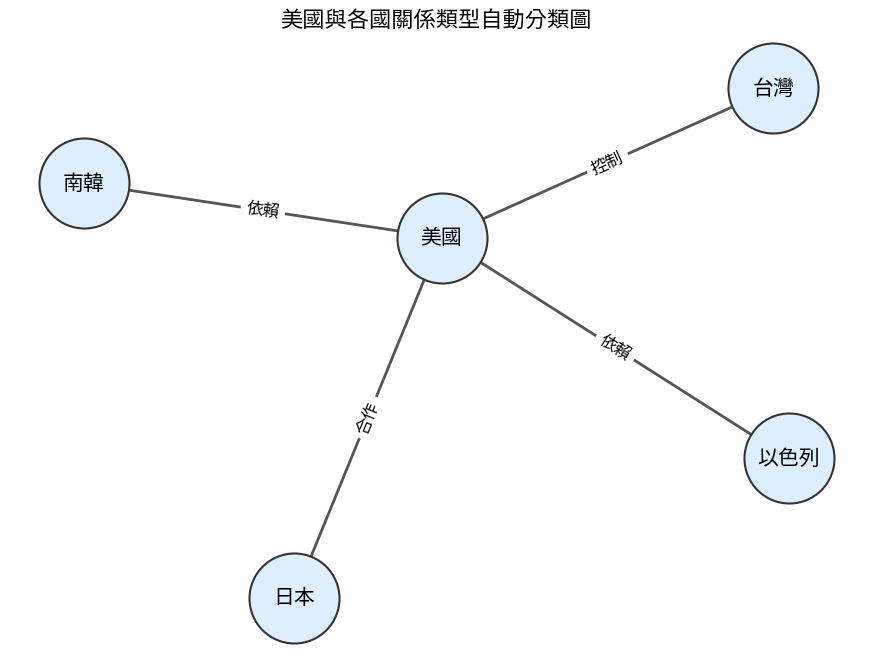

In [ ]:
# 畫關係圖

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager


# 請改成你自己的字型路徑
font_path = "./TaipeiSansTCBeta-Regular.ttf"
fontManager.addfont(font_path)
plt.rcParams["font.sans-serif"] = ["Taipei Sans TC Beta"]
plt.rcParams["axes.unicode_minus"] = False

G = nx.DiGraph()

for _, row in relation_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        relation=row["relation"],
        weight=row["score"]
    )

pos = nx.spring_layout(G, seed=42, k=1.5)

plt.figure(figsize=(11, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4200,
    node_color="#DDEEFF",
    edgecolors="#333333",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=22,
    width=2,
    edge_color="#555555"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=15,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "relation")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=12
)

plt.title("美國與各國關係類型自動分類圖", fontsize=16)
plt.axis("off")
plt.show()

In [ ]:
# CKIP套用於資料集

# 以前50筆資料作為範例
text = metaData['sentence'].tolist()
text = text[:50]

# 執行處理
ws = ws_driver(text)#斷詞
pos = pos_driver(ws) # POS
ner = ner_driver(text) # NER

#將斷詞以及 pos 結果合在一起顯示
def pack_ws_pos_sentece(sentence_ws, sentence_pos):
  assert len(sentence_ws) == len(sentence_pos)#確認斷斷詞和POS的長度相同
  res = []
  for word_ws, word_pos in zip(sentence_ws, sentence_pos):
    res.append(f"{word_ws}({word_pos})") #合在-起
  return "\u3000".join(res)

sentences, packed_sentences, entities = [], [], []

# 儲存結果
for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
  sentences.append(sentence)
  packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
  entities.append([str(entity) for entity in sentence_ner])

# 將結果存在一個 dataframe 中
ner_results = pd.DataFrame({
    'sentence': sentences,
    'packed_sentence': packed_sentences,
    'entities': entities
})

ner_results.head(10)

Inference: 100%|██████████| 1/1 [01:16<00:00, 76.28s/it]


,sentence,packed_sentence,entities
0,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,聯合(VC) 台股(Na) 大盤(Na) 漲(VH) 基層(A) 無(VJ) 感(VK) 雞...,"[NerToken(word='葉德正', ner='PERSON', idx=(27, 3..."
1,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...,美國(Nc) 以色列(Nc) 日本(Nc) 南韓(Nc) 台灣(Nc) 關係(Na) 網(N...,"[NerToken(word='美國', ner='GPE', idx=(0, 2)), N..."
2,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...,干(VC) 你(Nh) 中分(VH) 龜頭(Na) 都(D) 了(T) 還(D) 在(P) ...,"[NerToken(word='台灣', ner='GPE', idx=(12, 14)),..."
3,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...,媒體(Na) 來源(Na) 自由時報(P) 記者(Na) 署名(Nc) 葛祐豪(Nb) 完整...,"[NerToken(word='葛祐豪', ner='PERSON', idx=(12, 1..."
4,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,不(D) 存(VA) 股(Na) 的(DE) 人(Na) 就(D) 跟(P) 大雄(Nb) ...,"[NerToken(word='大雄', ner='GPE', idx=(7, 9)), N..."
5,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...,早(D) 在(P) 川普(Nb) 上任(VH) 之前(Ng) 就(D) 有(V_2) 說法(...,"[NerToken(word='川普', ner='PERSON', idx=(2, 4))..."
6,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...,媒體(Na) 來源(Na) 聯合(D) 記者(Na) 署名(Na) 聯合報(Na) 記者(N...,"[NerToken(word='徐白櫻', ner='PERSON', idx=(15, 1..."
7,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,一(Neu) 整(Neqa) 年(Nf) 如果(Cbb) 認真(VH) 應該(D) 可以(D...,"[NerToken(word='一整年', ner='DATE', idx=(0, 3)),..."
8,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,築(VC) 颱(Na) 行(VA) 示(VE) 大上(VH) 每(Nes) 屋(Na) 評利...,"[NerToken(word='輝達', ner='PERSON', idx=(36, 38..."
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,因為(Cbb) 大(VH) 模型(Na) 在(P) 運算(VC) 的(DE) 時候(Na) ...,"[NerToken(word='北大', ner='ORG', idx=(40, 42))]"


## 4.Sequence classification

### 4.1 Sentiment Classification

#### (1) 助教範例模型

In [ ]:
# 助教的範例模型
# 情緒分數是一到五分，從semi-negation 到 positive

model_name = "techthiyanes/chinese_sentiment"
model = pipeline('sentiment-analysis', model=model_name)

text =[
    "美國、以色列、日本、南韓、台灣關係網用親屬關係來區分",
    "美國：家族中的糖果爸爸，唯一的金主與規矩制定者",
    "以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決策，關係本質：我罩你，你幫我在中東當前線堡壘。",
    "日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。",
    "南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重要，但不要亂來，我還是你爸。",
    "台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底撕破臉，所以始終不給他進家譜。私生子手裡握著爸爸最需要的救命藥，所以糖果爸爸會私下塞武器給他保命，關係本質：我不能公開承認你，但你不能倒。"
]
result = model(text)
result

config.json:   0%|          | 0.00/864 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/409M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: techthiyanes/chinese_sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/409M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'star 4', 'score': 0.6573141813278198},
 {'label': 'star 4', 'score': 0.618437647819519},
 {'label': 'star 4', 'score': 0.6306865811347961},
 {'label': 'star 4', 'score': 0.6673871278762817},
 {'label': 'star 4', 'score': 0.6903601884841919},
 {'label': 'star 4', 'score': 0.42006027698516846}]

In [ ]:
#建立一個新的dataframe 來儲存結果
results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
results_df['sentence'] = metaData['sentence']

# 定義一個函數來進行情緒分析
def analyze_sentiment(sentence):
  # 確保輸入句子的長度不超過模型最大限制，避免 RuntimeError
  result = model([sentence], truncation=True, max_length=512)
  return pd.Series([result[0]['label'], result[0]['score']])

#使用apply 函數來進行情緒分析
results_df[['label', 'score']] = metaData['sentence'].apply(analyze_sentiment)

# 輸出結果
results_df.head(10)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,sentence,label,score
0,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,star 4,0.438917
1,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...,star 5,0.389849
2,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...,star 1,0.301823
3,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...,star 5,0.544326
4,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,star 5,0.422677
5,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...,star 5,0.433578
6,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...,star 5,0.576037
7,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,star 4,0.496198
8,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,star 5,0.436536
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,star 1,0.397340


#### (2) 自己找模型




In [ ]:
model_name = "hw2942/bert-base-chinese-finetuning-financial-news-sentiment-v2"
model = pipeline('sentiment-analysis', model=model_name)

text =[
    "美國、以色列、日本、南韓、台灣關係網用親屬關係來區分",
    "美國：家族中的糖果爸爸，唯一的金主與規矩制定者",
    "以色列：被包養的乾女兒，最偏心的那一個，名義上美國是乾爹，但以色列常常含老二就能左右美國的決策，關係本質：我罩你，你幫我在中東當前線堡壘。",
    "日本：嫡長子，二戰後被美國收養與重建，關係本質：你是我培養最成功的孩子，現在該接一些家業。",
    "南韓：叛逆但很能打的二兒子，情緒多、民族主義強，常在聽話與想獨立之間擺盪，關係本質：「你很重要，但不要亂來，我還是你爸。",
    "台灣：沒有正式名分但不能出事的私生子，全世界都知道他是爸爸的骨肉，但因為爸爸怕跟鄰居大戶徹底撕破臉，所以始終不給他進家譜。私生子手裡握著爸爸最需要的救命藥，所以糖果爸爸會私下塞武器給他保命，關係本質：我不能公開承認你，但你不能倒。"
]
result = model(text)
result

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/409M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: hw2942/bert-base-chinese-finetuning-financial-news-sentiment-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/409M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[{'label': 'Neutral', 'score': 0.9998643398284912},
 {'label': 'Neutral', 'score': 0.9998748302459717},
 {'label': 'Neutral', 'score': 0.9998618364334106},
 {'label': 'Neutral', 'score': 0.9998261332511902},
 {'label': 'Neutral', 'score': 0.9998341798782349},
 {'label': 'Neutral', 'score': 0.9998589754104614}]

In [ ]:
#建立一個新的dataframe 來儲存結果
results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])

results_df['system_id'] = metaData['system_id'].values
results_df['artTitle'] = metaData['artTitle'].values
results_df['artCatagory'] = metaData['artCatagory'].values
results_df['sentence'] = metaData['sentence'].values

# 定義一個函數來進行情緒分析
def analyze_sentiment(sentence):
  # 確保輸入句子的長度不超過模型最大限制，避免 RuntimeError
  result = model([sentence], truncation=True, max_length=512)
  return pd.Series([result[0]['label'], result[0]['score']])

#使用apply 函數來進行情緒分析
results_df[['label', 'score']] = metaData['sentence'].apply(analyze_sentiment)

# 輸出結果
results_df.head(10)

,sentence,label,score,system_id,artTitle,artCatagory
0,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,Positive,0.951059,1,[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping
1,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...,Neutral,0.999877,2,[問卦]美國版的我們這一家這樣行嗎,Gossiping
2,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...,Neutral,0.999581,3,[問卦]韌性是可以多萬用？不膩嗎？,Gossiping
3,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...,Neutral,0.999619,4,[新聞]台積電高雄廠2奈米量產市府:高雄躍升全,Gossiping
4,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,Negative,0.990662,5,Re:[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping
5,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...,Neutral,0.999763,6,Re:[問卦]經濟學人：台灣應思考開戰後美不出兵應,Gossiping
6,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...,Positive,0.996966,7,[新聞]台積電高雄2奈米廠正式量產新增2匝道及,Gossiping
7,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,Positive,0.998846,8,[問卦]2025台灣有完成什麼大事嗎？,Gossiping
8,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,Neutral,0.999792,9,Re:[新聞]新規必看！千坪大樓必須裝太陽光電 要能承受17級強陣風,Gossiping
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,Neutral,0.999788,10,Re:[問卦]ai訓練為什麼一定要記憶體？,Gossiping


#### ＃(3) 情緒探索分析（自行新增）

前面使用中文金融新聞情緒模型，針對 metaData 中每一句文本進行情緒分類，<br/>
並取得每一句的情緒標籤與模型信心分數。<br/>
<br/>
本段進一步整理情緒分析結果，<br/>
觀察整體資料中正向、負向與中性情緒的分布情形，<br/>
並檢視不同情緒類別的代表句。

本主題聚焦於 PTT 使用者對 NVIDIA、AI 晶片、半導體與股市投資議題的討論，<br/>
因此情緒探索分析可以補充前面 RQ3 的投資態度分析<br/>

也就是說 RQ3 主要透過規則式詞典判斷使用者偏向看好、觀望或看壞；<br/>
而本段則使用預訓練情緒分類模型，從語句本身判斷其整體情緒傾向，<br/>
進一步了解社群討論中是否偏向樂觀、保守或負面情緒。


In [ ]:
# 4.1 (3) 情緒探索分析：分主題的模型情緒分析

# 建立分析用資料表
sentiment_topic_df = results_df.copy()

# 保留原始句子
sentiment_topic_df["sentence"] = sentiment_topic_df["sentence"].astype(str)

# 查看模型原始情緒標籤
print("模型原始情緒標籤：")
print(sentiment_topic_df["label"].value_counts())

sentiment_topic_df.head(10)

模型原始情緒標籤：
label
Neutral     770
Negative    360
Positive    125
Name: count, dtype: int64


,sentence,label,score,system_id,artTitle,artCatagory
0,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,Positive,0.951059,1,[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping
1,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...,Neutral,0.999877,2,[問卦]美國版的我們這一家這樣行嗎,Gossiping
2,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...,Neutral,0.999581,3,[問卦]韌性是可以多萬用？不膩嗎？,Gossiping
3,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...,Neutral,0.999619,4,[新聞]台積電高雄廠2奈米量產市府:高雄躍升全,Gossiping
4,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,Negative,0.990662,5,Re:[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping
5,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...,Neutral,0.999763,6,Re:[問卦]經濟學人：台灣應思考開戰後美不出兵應,Gossiping
6,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...,Positive,0.996966,7,[新聞]台積電高雄2奈米廠正式量產新增2匝道及,Gossiping
7,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,Positive,0.998846,8,[問卦]2025台灣有完成什麼大事嗎？,Gossiping
8,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,Neutral,0.999792,9,Re:[新聞]新規必看！千坪大樓必須裝太陽光電 要能承受17級強陣風,Gossiping
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,Neutral,0.999788,10,Re:[問卦]ai訓練為什麼一定要記憶體？,Gossiping


In [ ]:
# 設定主題分類關鍵詞
# 這裡是「主題分類」，不是投資態度分類

topic_keywords = {
    "AI晶片與NVIDIA": [
        "NVIDIA", "輝達", "黃仁勳", "GPU", "AI晶片",
        "H100", "H200", "B200", "GB200", "GB300", "BLACKWELL"
    ],
    "台積電與半導體供應鏈": [
        "台積電", "TSMC", "半導體", "晶片", "COWOS",
        "先進製程", "封裝", "供應鏈", "廣達", "緯創",
        "緯穎", "鴻海", "奇鋐", "雙鴻", "台達電"
    ],
    "股價財報與投資討論": [
        "股票", "股價", "台股", "美股", "財報", "營收",
        "獲利", "法人", "外資", "投信", "本益比",
        "目標價", "創高", "大漲", "大跌", "追高",
        "套牢", "泡沫", "風險"
    ],
    "AI伺服器與資料中心": [
        "AI伺服器", "伺服器", "資料中心", "散熱",
        "雲端", "算力", "運算", "電力", "機櫃"
    ],
    "國際政治與科技競爭": [
        "美國", "中國", "川普", "關稅", "出口管制",
        "制裁", "科技戰", "貿易戰", "日本", "韓國",
        "以色列", "伊朗"
    ]
}

In [ ]:
# 建立主題分類函式

def classify_topic_by_keywords(text):
    text = str(text).upper()

    topic_scores = {}

    for topic, keywords in topic_keywords.items():
        score = 0
        for keyword in keywords:
            if keyword.upper() in text:
                score += 1
        topic_scores[topic] = score

    max_topic = max(topic_scores, key=topic_scores.get)

    if topic_scores[max_topic] == 0:
        return "其他"
    else:
        return max_topic

In [ ]:
# 套用主題分類
sentiment_topic_df["topic_category"] = sentiment_topic_df["sentence"].apply(
    classify_topic_by_keywords
)

print("主題分類結果：")
print(sentiment_topic_df["topic_category"].value_counts())

sentiment_topic_df.head(10)

主題分類結果：
topic_category
台積電與半導體供應鏈     621
股價財報與投資討論      329
國際政治與科技競爭      188
AI晶片與NVIDIA     41
AI伺服器與資料中心      39
其他              37
Name: count, dtype: int64


,sentence,label,score,system_id,artTitle,artCatagory,sentiment_zh,topic_category
0,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,Positive,0.951059,1,[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping,Positive,股價財報與投資討論
1,美國以色列日本南韓台灣關係網用親屬關係來區分美國家族中的唯一的金主與規矩制定者以色列被包養的...,Neutral,0.999877,2,[問卦]美國版的我們這一家這樣行嗎,Gossiping,Neutral,國際政治與科技競爭
2,干你中分龜頭都了還在韌性台灣經歷了賤賣台積電馬太鞍偃塞湖事件台南風災事件強力譴責中共實彈研習...,Neutral,0.999581,3,[問卦]韌性是可以多萬用？不膩嗎？,Gossiping,Neutral,台積電與半導體供應鏈
3,媒體來源自由時報記者署名葛祐豪完整新聞標題台積電高雄廠奈米量產市府高雄躍升全球先進半導體製程...,Neutral,0.999619,4,[新聞]台積電高雄廠2奈米量產市府:高雄躍升全,Gossiping,Neutral,台積電與半導體供應鏈
4,不存股的人就跟大雄一樣是廢物你沒辦法選擇父母但你可以選擇存股好好選積優電子股趁股價下殺成交量...,Negative,0.990662,5,Re:[新聞]台股大盤漲基層無感雞腿便當130...帳單,Gossiping,Negative,台積電與半導體供應鏈
5,早在川普上任之前就有說法好嗎到底為什麼還有人在相信美國美國這麼多歷史藉戰爭發財最近一次烏克蘭...,Neutral,0.999763,6,Re:[問卦]經濟學人：台灣應思考開戰後美不出兵應,Gossiping,Neutral,國際政治與科技競爭
6,媒體來源聯合記者署名聯合報記者徐白櫻高雄即時報導完整新聞標題台積電高雄奈米廠正式量產新增匝道...,Positive,0.996966,7,[新聞]台積電高雄2奈米廠正式量產新增2匝道及,Gossiping,Positive,台積電與半導體供應鏈
7,一整年如果認真應該可以完成不少事何況預算又創新高不然過去八年累積下來應該會有什麼重大建設完工...,Positive,0.998846,8,[問卦]2025台灣有完成什麼大事嗎？,Gossiping,Positive,國際政治與科技競爭
8,築颱行示大上每屋評利類足模新出條評家需有專家知道大概還要多少光電板才能讓輝達在台灣設廠阿記得...,Neutral,0.999792,9,Re:[新聞]新規必看！千坪大樓必須裝太陽光電 要能承受17級強陣風,Gossiping,Neutral,AI晶片與NVIDIA
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作那你猜猜為什麼叫大模型就是靠北大我運作一...,Neutral,0.999788,10,Re:[問卦]ai訓練為什麼一定要記憶體？,Gossiping,Neutral,AI伺服器與資料中心


In [ ]:
# 各看板的主題分布

category_topic_count = pd.crosstab(
    sentiment_topic_df["artCatagory"],
    sentiment_topic_df["topic_category"]
)

category_topic_ratio = pd.crosstab(
    sentiment_topic_df["artCatagory"],
    sentiment_topic_df["topic_category"],
    normalize="index"
)

print("各看板的主題分布筆數：")
display(category_topic_count)

print("各看板的主題分布比例：")
display(category_topic_ratio)

各看板的主題分布筆數：


topic_category,AI伺服器與資料中心,AI晶片與NVIDIA,其他,台積電與半導體供應鏈,國際政治與科技競爭,股價財報與投資討論
artCatagory,,,,,,
Gossiping,19,30,30,410,143,88
Stock,20,11,7,211,45,241


各看板的主題分布比例：


topic_category,AI伺服器與資料中心,AI晶片與NVIDIA,其他,台積電與半導體供應鏈,國際政治與科技競爭,股價財報與投資討論
artCatagory,,,,,,
Gossiping,0.026389,0.041667,0.041667,0.569444,0.198611,0.122222
Stock,0.037383,0.020561,0.013084,0.394393,0.084112,0.450467


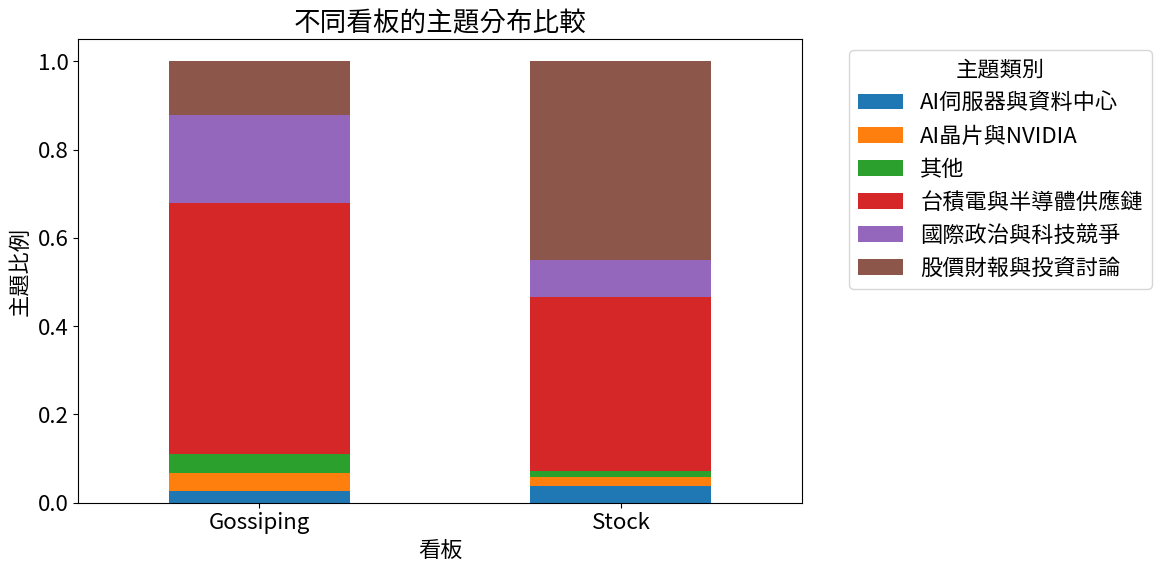

In [ ]:
# 各看板的主題分布比例圖

category_topic_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("不同看板的主題分布比較")
plt.xlabel("看板")
plt.ylabel("主題比例")
plt.xticks(rotation=0)
plt.legend(title="主題類別", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

各主題內部的看板來源比例：


artCatagory,Gossiping,Stock
topic_category,,
AI伺服器與資料中心,0.487179,0.512821
AI晶片與NVIDIA,0.731707,0.268293
其他,0.810811,0.189189
台積電與半導體供應鏈,0.660225,0.339775
國際政治與科技競爭,0.760638,0.239362
股價財報與投資討論,0.267477,0.732523


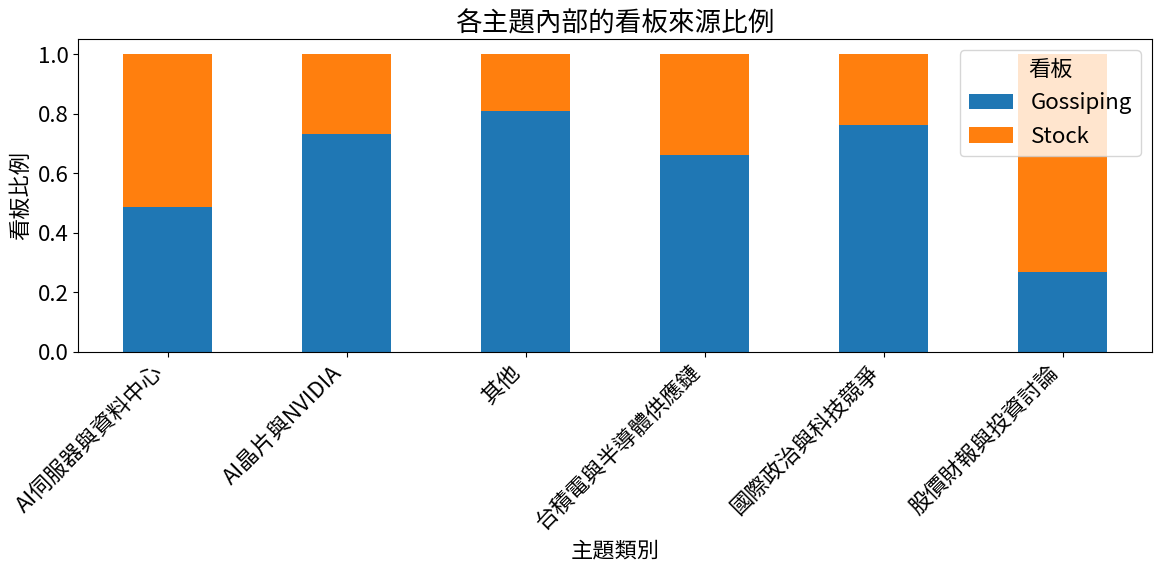

In [ ]:
# 各主題內部的看板來源比例

topic_category_ratio = pd.crosstab(
    sentiment_topic_df["topic_category"],
    sentiment_topic_df["artCatagory"],
    normalize="index"
)

print("各主題內部的看板來源比例：")
display(topic_category_ratio)

topic_category_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("各主題內部的看板來源比例")
plt.xlabel("主題類別")
plt.ylabel("看板比例")
plt.xticks(rotation=45, ha="right")
plt.legend(title="看板")
plt.tight_layout()
plt.show()

In [ ]:
# 各看板 × 主題 × 情緒筆數

category_topic_sentiment_count = pd.crosstab(
    index=[
        sentiment_topic_df["artCatagory"],
        sentiment_topic_df["topic_category"]
    ],
    columns=sentiment_topic_df["label"]
)

print("各看板 × 主題 × 情緒筆數：")
display(category_topic_sentiment_count)

各看板 × 主題 × 情緒筆數：


label                       Negative  Neutral  Positive
artCatagory topic_category                             
Gossiping   AI伺服器與資料中心             5       12         2
            AI晶片與NVIDIA            4       26         0
            其他                     4       26         0
            台積電與半導體供應鏈            95      282        33
            國際政治與科技競爭             36      101         6
            股價財報與投資討論             44       39         5
Stock       AI伺服器與資料中心             4       13         3
            AI晶片與NVIDIA            3        7         1
            其他                     0        7         0
            台積電與半導體供應鏈            46      145        20
            國際政治與科技競爭             22       21         2
            股價財報與投資討論             97       91        53

In [ ]:
# 各看板 × 主題 × 情緒比例
# 每一組 artCatagory × topic_category 加總為 100%

category_topic_sentiment_ratio = pd.crosstab(
    index=[
        sentiment_topic_df["artCatagory"],
        sentiment_topic_df["topic_category"]
    ],
    columns=sentiment_topic_df["label"],
    normalize="index"
)

print("各看板 × 主題 × 情緒比例：")
display(category_topic_sentiment_ratio)

各看板 × 主題 × 情緒比例：


label                       Negative   Neutral  Positive
artCatagory topic_category                              
Gossiping   AI伺服器與資料中心      0.263158  0.631579  0.105263
            AI晶片與NVIDIA     0.133333  0.866667  0.000000
            其他              0.133333  0.866667  0.000000
            台積電與半導體供應鏈      0.231707  0.687805  0.080488
            國際政治與科技競爭       0.251748  0.706294  0.041958
            股價財報與投資討論       0.500000  0.443182  0.056818
Stock       AI伺服器與資料中心      0.200000  0.650000  0.150000
            AI晶片與NVIDIA     0.272727  0.636364  0.090909
            其他              0.000000  1.000000  0.000000
            台積電與半導體供應鏈      0.218009  0.687204  0.094787
            國際政治與科技競爭       0.488889  0.466667  0.044444
            股價財報與投資討論       0.402490  0.377593  0.219917

In [ ]:
# 情緒類別的平均模型信心分數

category_topic_score_summary = sentiment_topic_df.groupby(
    ["artCatagory", "topic_category", "label"]
)["score"].agg(
    count="count",
    mean_score="mean",
    max_score="max",
    min_score="min"
).reset_index()

print("各看板 × 主題 × 情緒類別的模型信心分數：")
display(category_topic_score_summary)

各看板 × 主題 × 情緒類別的模型信心分數：


,artCatagory,topic_category,label,count,mean_score,max_score,min_score
0,Gossiping,AI伺服器與資料中心,Negative,5,0.987410,0.999553,0.940749
1,Gossiping,AI伺服器與資料中心,Neutral,12,0.998262,0.999867,0.982249
2,Gossiping,AI伺服器與資料中心,Positive,2,0.944818,0.999114,0.890522
3,Gossiping,AI晶片與NVIDIA,Negative,4,0.998556,0.999406,0.997265
4,Gossiping,AI晶片與NVIDIA,Neutral,26,0.980571,0.999871,0.709000
5,Gossiping,其他,Negative,4,0.998797,0.999581,0.996773
6,Gossiping,其他,Neutral,26,0.988672,0.999882,0.723242
7,Gossiping,台積電與半導體供應鏈,Negative,95,0.967916,0.999810,0.619403
8,Gossiping,台積電與半導體供應鏈,Neutral,282,0.987484,0.999880,0.514445
9,Gossiping,台積電與半導體供應鏈,Positive,33,0.976577,0.999853,0.670627


In [ ]:
# 不同 artCatagory 的 topic_category 平均情緒分數圖


def convert_sentiment_score(row):
    label = str(row["label"]).lower()

    if label == "positive":
        return row["score"]
    elif label == "negative":
        return -row["score"]
    elif label == "neutral":
        return 0
    else:
        return np.nan

sentiment_topic_df["sentiment_direction_score"] = sentiment_topic_df.apply(
    convert_sentiment_score,
    axis=1
)

category_topic_score = sentiment_topic_df.groupby(
    ["artCatagory", "topic_category"]
)["sentiment_direction_score"].mean().reset_index()

category_topic_score.columns = [
    "artCatagory",
    "topic_category",
    "mean_sentiment_score"
]

print("不同 artCatagory 的 topic_category 平均情緒分數：")
display(category_topic_score)

不同 artCatagory 的 topic_category 平均情緒分數：


,artCatagory,topic_category,mean_sentiment_score
0,Gossiping,AI伺服器與資料中心,-0.160390
1,Gossiping,AI晶片與NVIDIA,-0.133141
2,Gossiping,其他,-0.133173
3,Gossiping,台積電與半導體供應鏈,-0.145671
4,Gossiping,國際政治與科技競爭,-0.203435
5,Gossiping,股價財報與投資討論,-0.423598
6,Stock,AI伺服器與資料中心,-0.048298
7,Stock,AI晶片與NVIDIA,-0.150628
8,Stock,其他,0.000000
9,Stock,台積電與半導體供應鏈,-0.114594


In [ ]:
# 轉成矩陣格式

category_topic_score_matrix = category_topic_score.pivot(
    index="topic_category",
    columns="artCatagory",
    values="mean_sentiment_score"
)

print("不同看板中各主題的平均情緒分數：")
display(category_topic_score_matrix)

不同看板中各主題的平均情緒分數：


artCatagory,Gossiping,Stock
topic_category,,
AI伺服器與資料中心,-0.160390,-0.048298
AI晶片與NVIDIA,-0.133141,-0.150628
其他,-0.133173,0.000000
台積電與半導體供應鏈,-0.145671,-0.114594
國際政治與科技競爭,-0.203435,-0.423834
股價財報與投資討論,-0.423598,-0.172701


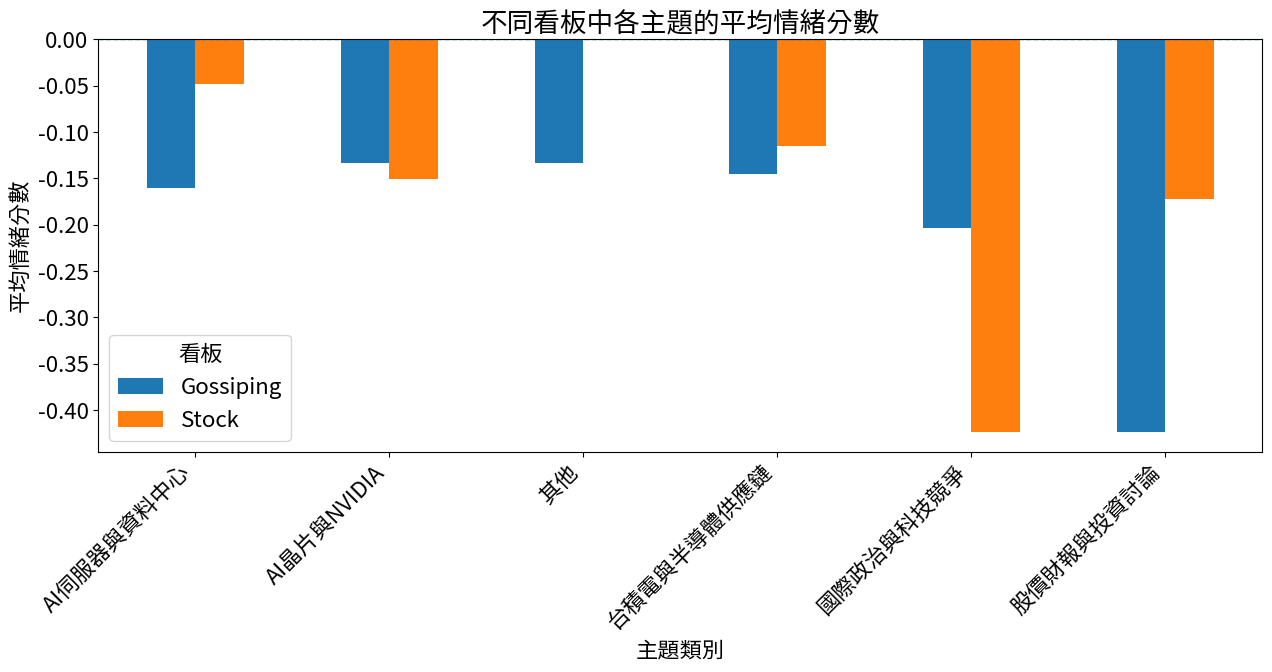

In [ ]:
# 不同看板中各主題的平均情緒分數圖

category_topic_score_matrix.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("不同看板中各主題的平均情緒分數")
plt.xlabel("主題類別")
plt.ylabel("平均情緒分數")
plt.xticks(rotation=45, ha="right")
plt.legend(title="看板")
plt.tight_layout()
plt.show()

In [ ]:
# 查看相同 topic_category 下，不同 artCatagory 的代表句

def show_topic_category_examples(topic, sentiment=None, n=5):
    df = sentiment_topic_df[
        sentiment_topic_df["topic_category"] == topic
    ].copy()

    # 如果有指定情緒，就進一步篩選
    if sentiment is not None:
        df = df[df["label"].str.lower() == sentiment.lower()].copy()

    # 依照模型信心分數排序
    df = df.sort_values("score", ascending=False)

    # 分不同 artCatagory 顯示代表句
    results = {}

    for category in df["artCatagory"].dropna().unique():
        temp = df[df["artCatagory"] == category].copy()

        results[category] = temp[[
            "artCatagory",
            "topic_category",
            "sentence",
            "label",
            "score"
        ]].head(n)

    return results

In [ ]:
# 股價財報與投資討論主題中的正向句子
examples = show_topic_category_examples(
    topic="股價財報與投資討論",
    sentiment="positive",
    n=5
)

for category, df in examples.items():
    print(f"\n看板：{category}")
    display(df)


看板：Stock


,artCatagory,topic_category,sentence,label,score
768,Stock,股價財報與投資討論,原文標題台積市值躍全球第六大收盤較台股現貨溢價原文連結發布時間記者署名編譯易起宇記者黃彥宏原...,Positive,0.999799
783,Stock,股價財報與投資討論,原文標題半導體台積電飆元新天價市值衝破兆原文連結發布時間記者署名時報資訊林資傑原文內容晶圓代...,Positive,0.999787
966,Stock,股價財報與投資討論,原文標題韓國綜合股價指數盤中突破點連續第三個交易日上漲點原文連結發布時間輸入年月日上午更正年...,Positive,0.999753
1066,Stock,股價財報與投資討論,原文標題波若威自結月獲利萬元元原文連結發布時間記者署名經濟日報記者秦鈺翔原文內容波若威日達公...,Positive,0.999739
1141,Stock,股價財報與投資討論,原文標題日本台灣同步擴產禾伸堂強攻電源原文連結發布時間記者署名工商時報李淑惠原文內容禾伸堂強...,Positive,0.999736



看板：Gossiping


,artCatagory,topic_category,sentence,label,score
52,Gossiping,股價財報與投資討論,不管會泡沫還是落地成功現在就是正在漲而且台廠一堆公司吃到紅利台灣也都紅利貢獻你不買就是沒有跟...,Positive,0.999735
183,Gossiping,股價財報與投資討論,媒體來源經濟日報記者署名盧宏奇完整新聞標題券商公會今年台股上看將推動八項工作壯大資本市場完整...,Positive,0.999701
231,Gossiping,股價財報與投資討論,愛爾蘭是著名的妖精經濟光是蘋果等外商灌注的獲利就讓每年成長趴現在人均已經破萬鎂臺灣則是光靠台...,Positive,0.999333
99,Gossiping,股價財報與投資討論,備註請放最後面違者新聞文章刪除媒體來源記者署名記者劉彥萱攝影黃冠瑋責任編輯新聞中心報導完整新...,Positive,0.995027
0,Gossiping,股價財報與投資討論,聯合台股大盤漲基層無感雞腿便當帳單漲比較有感聯合報記者葉德正新北即時報導台股屢創新高但對不少...,Positive,0.951059


In [ ]:
# 各主題 × 各看板 × 各情緒代表句

for topic in sentiment_topic_df["topic_category"].dropna().unique():
    print("\n" + "="*80)
    print(f"主題：{topic}")
    print("="*80)

    for sentiment in ["positive", "neutral", "negative"]:
        print(f"\n情緒：{sentiment}")

        examples = show_topic_category_examples(
            topic=topic,
            sentiment=sentiment,
            n=3
        )

        for category, df in examples.items():
            print(f"\n看板：{category}")
            display(df)


主題：股價財報與投資討論

情緒：positive

看板：Stock


,artCatagory,topic_category,sentence,label,score
768,Stock,股價財報與投資討論,原文標題台積市值躍全球第六大收盤較台股現貨溢價原文連結發布時間記者署名編譯易起宇記者黃彥宏原...,Positive,0.999799
783,Stock,股價財報與投資討論,原文標題半導體台積電飆元新天價市值衝破兆原文連結發布時間記者署名時報資訊林資傑原文內容晶圓代...,Positive,0.999787
966,Stock,股價財報與投資討論,原文標題韓國綜合股價指數盤中突破點連續第三個交易日上漲點原文連結發布時間輸入年月日上午更正年...,Positive,0.999753



看板：Gossiping


,artCatagory,topic_category,sentence,label,score
52,Gossiping,股價財報與投資討論,不管會泡沫還是落地成功現在就是正在漲而且台廠一堆公司吃到紅利台灣也都紅利貢獻你不買就是沒有跟...,Positive,0.999735
183,Gossiping,股價財報與投資討論,媒體來源經濟日報記者署名盧宏奇完整新聞標題券商公會今年台股上看將推動八項工作壯大資本市場完整...,Positive,0.999701
231,Gossiping,股價財報與投資討論,愛爾蘭是著名的妖精經濟光是蘋果等外商灌注的獲利就讓每年成長趴現在人均已經破萬鎂臺灣則是光靠台...,Positive,0.999333



情緒：neutral

看板：Gossiping


...

,artCatagory,topic_category,sentence,label,score
290,Gossiping,其他,據任何人只要有萬美金都可以參加慈善撲克王大賽了解賭俠沒錢向海珊借美金贏到萬美金參加慈善撲克王...,Neutral,0.999882
474,Gossiping,其他,台灣發展過疫苗國家隊口罩國家隊快篩國家隊雞蛋國家隊綠能國家隊打詐國家隊根本國家隊大國,Neutral,0.999880
339,Gossiping,其他,我來翻譯一下缺電缺電缺電火力火力火力什麼減碳全部規劃都是火力早說非核家園的結果直通火力家園最...,Neutral,0.999868



看板：Stock


,artCatagory,topic_category,sentence,label,score
987,Stock,其他,這邊提供一個例子年高盛調降海力士那時明顯就送分題我還噴了一下高盛然後瘋狂推那時候海力士現在半...,Neutral,0.999847
1099,Stock,其他,剛剛看到的一個快報說跟的合作維持不變到底那個是真的呢棄賃片人且宮部初是元有展網支直產量約測人...,Neutral,0.999745
1144,Stock,其他,可以看馬斯克的歷史他開什麼公司有失敗過好像都成功對吧之前火箭公司電動車公司哪個不是在被唱衰之...,Neutral,0.999559



情緒：negative

看板：Gossiping


,artCatagory,topic_category,sentence,label,score
245,Gossiping,其他,名校畢業生不可能罵一罵就走吧名校碩士班早就被指導教授洗禮過了如果是不懂被罵都馬可以吞會走通常...,Negative,0.999581
53,Gossiping,其他,同事手上有張大概是左右抱到現在最近一兩個月發現他講話聲音越來越大聲工作越來越擺爛請問這樣正常嗎,Negative,0.999479
591,Gossiping,其他,很可惜放假去地中海玩最後出事死在地中海要是沒死他那時候匯率很好現在應該在巴黎有好幾間房享受著...,Negative,0.999355


### 4.2 Relation Extraction (RE)

In [ ]:
# REBEL Relation Extraction
# 本段使用 REBEL 模型嘗試進行關係抽取，並將結果整理成以 United States 為中心的二元關係圖。

!pip install transformers sentencepiece networkx matplotlib pandas -q

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 載入 REBEL 模型
# REBEL 是 seq2seq 生成式模型，不是 text-classification 模型

model_name = "Babelscape/rebel-large"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# 2. 英文文本
# 這裡將中文文本翻譯為英文，是因為 REBEL 對英文文本的關係抽取效果通常比較穩定

text_en = [
    "The United States is the main sponsor and rule maker in this family-like relationship network.",

    "Israel is described as the favored daughter of the United States. The United States acts as Israel's protector, while Israel serves as a frontline fortress for the United States in the Middle East.",

    "Japan is described as the eldest son of the United States. After World War II, Japan was rebuilt and supported by the United States. Japan is expected to inherit part of the United States' regional responsibilities.",

    "South Korea is described as a rebellious but important son of the United States. South Korea is an important ally, but the United States still tries to influence and control its strategic decisions.",

    "Taiwan is described as an unofficial child of the United States. The United States cannot formally recognize Taiwan, but it provides weapons and security support to prevent Taiwan from falling."
]

for i, sentence in enumerate(text_en):
    print(f"{i+1}. {sentence}")

# 3. REBEL 輸出解析函式
# 將 REBEL 生成結果轉成 head-relation-tail 三元組

def extract_triplets(text):
    triplets = []
    relation, subject, object_ = "", "", ""
    current = None

    text = text.strip()
    tokens = text.replace("<s>", "").replace("<pad>", "").replace("</s>", "").split()

    for token in tokens:
        if token == "<triplet>":
            if subject and relation and object_:
                triplets.append({
                    "head": subject.strip(),
                    "relation": relation.strip(),
                    "tail": object_.strip()
                })

            subject, relation, object_ = "", "", ""
            current = "subject"

        elif token == "<subj>":
            current = "object"

        elif token == "<obj>":
            current = "relation"

        else:
            if current == "subject":
                subject += " " + token
            elif current == "object":
                object_ += " " + token
            elif current == "relation":
                relation += " " + token

    if subject and relation and object_:
        triplets.append({
            "head": subject.strip(),
            "relation": relation.strip(),
            "tail": object_.strip()
        })

    return triplets

# 3-1. 清理 REBEL 抽取結果

def clean_entity_name(text):
    text = str(text).strip()

    # 常見國家名稱
    known_entities = [
        "United States",
        "Israel",
        "Japan",
        "South Korea",
        "Taiwan",
        "Middle East"
    ]

    # 如果欄位裡有重複或混雜文字，只保留有出現的已知實體
    matched = []

    for entity in known_entities:
        if entity in text:
            matched.append(entity)

    # 如果只有一個已知實體，就回傳它
    if len(matched) == 1:
        return matched[0]

    # 如果有多個，先回傳原文字，後面再處理
    if len(matched) > 1:
        return " | ".join(matched)

    return text


def clean_relation_text(text):
    text = str(text).strip()

    # 處理重複 relation，例如 diplomatic relation diplomatic relation
    words = text.split()
    cleaned_words = []

    for w in words:
        if len(cleaned_words) == 0 or cleaned_words[-1] != w:
            cleaned_words.append(w)

    cleaned = " ".join(cleaned_words)

    # 特別處理常見重複片語
    cleaned = cleaned.replace(
        "diplomatic relation diplomatic relation",
        "diplomatic relation"
    )

    return cleaned

# 4. 使用 REBEL 逐句抽取三元組

all_triplets = []

for sent_id, sentence in enumerate(text_en):

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    generated_tokens = model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        num_return_sequences=1
    )

    decoded = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=False
    )[0]

    triplets = extract_triplets(decoded)

    for triplet in triplets:
        triplet["sent_id"] = sent_id
        triplet["sentence"] = sentence
        triplet["raw_output"] = decoded
        all_triplets.append(triplet)

triplet_df = pd.DataFrame(all_triplets)

# 4-1. 清洗 REBEL 原始三元組

if not triplet_df.empty:
    triplet_df["head_clean"] = triplet_df["head"].apply(clean_entity_name)
    triplet_df["tail_clean"] = triplet_df["tail"].apply(clean_entity_name)
    triplet_df["relation_clean"] = triplet_df["relation"].apply(clean_relation_text)

    # 移除 head 或 tail 中包含多個國家的結果
    # 例如 Israel | Japan | South Korea | Taiwan 這種不適合做二元關係
    triplet_df_clean = triplet_df[
        ~triplet_df["head_clean"].str.contains(r"\|", regex=True, na=False) &
        ~triplet_df["tail_clean"].str.contains(r"\|", regex=True, na=False)
    ].copy()

    # 移除 head == tail 的結果
    triplet_df_clean = triplet_df_clean[
        triplet_df_clean["head_clean"] != triplet_df_clean["tail_clean"]
    ].copy()

else:
    triplet_df_clean = pd.DataFrame()

print("清洗後的 REBEL 三元組：")
display(
    triplet_df_clean[[
        "head_clean",
        "relation_clean",
        "tail_clean",
        "sent_id",
        "sentence"
    ]]
)

def clean_relation_text(text):
    text = str(text).strip()

    # 常見重複片語處理
    repeated_phrases = [
        "diplomatic relation",
        "part of",
        "country",
        "has part"
    ]

    for phrase in repeated_phrases:
        # 如果同一個 phrase 重複出現，只保留一次
        if phrase in text:
            count = text.count(phrase)
            if count > 1:
                text = phrase

    # 再處理連續重複單字
    words = text.split()
    cleaned_words = []

    for word in words:
        if len(cleaned_words) == 0 or cleaned_words[-1] != word:
            cleaned_words.append(word)

    return " ".join(cleaned_words)

    triplet_df_clean["relation_clean"] = triplet_df_clean["relation_clean"].apply(clean_relation_text)

# 5. 改成以 United States 為中心的二元關係
# 完全使用 REBEL 抽出的 relation，不使用人工 simple_relation_map

center_country = "United States"
target_countries = ["Israel", "Japan", "South Korea", "Taiwan"]

binary_relation_records = []

for target in target_countries:

    # 找出同時提到 United States 和 target 的句子
    related_sentences = [
        sent for sent in text_en
        if center_country in sent and target in sent
    ]

    related_relations = []

    if not triplet_df_clean.empty:
        for _, row in triplet_df_clean.iterrows():
            head = row["head_clean"]
            tail = row["tail_clean"]
            relation = row["relation_clean"]
            sentence = row["sentence"]

            # 只保留 United States 與 target 兩者之間的直接關係
            is_direct_pair = (
                (head == center_country and tail == target) or
                (head == target and tail == center_country)
            )

            if is_direct_pair:
                related_relations.append(relation)

            # 清理 relation 後再去重
            related_relations = [
                clean_relation_text(r)
                for r in related_relations
            ]

            # 移除空值與 no relation
            related_relations = [
                r for r in related_relations
                if r and r != "nan"
            ]

            # 去重
            related_relations = list(dict.fromkeys(related_relations))


    if len(related_relations) > 0:
        relation_label = " / ".join(related_relations)
    else:
        relation_label = "no relation extracted"

    binary_relation_records.append({
        "source": center_country,
        "target": target,
        "relation": relation_label,
        "evidence_sentence": " ".join(related_sentences)
    })

binary_relation_df = pd.DataFrame(binary_relation_records)

print("以 United States 為中心的二元關係表：")
display(binary_relation_df)



Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

1. The United States is the main sponsor and rule maker in this family-like relationship network.
2. Israel is described as the favored daughter of the United States. The United States acts as Israel's protector, while Israel serves as a frontline fortress for the United States in the Middle East.
3. Japan is described as the eldest son of the United States. After World War II, Japan was rebuilt and supported by the United States. Japan is expected to inherit part of the United States' regional responsibilities.
4. South Korea is described as a rebellious but important son of the United States. South Korea is an important ally, but the United States still tries to influence and control its strategic decisions.
5. Taiwan is described as an unofficial child of the United States. The United States cannot formally recognize Taiwan, but it provides weapons and security support to prevent Taiwan from falling.
清洗後的 REBEL 三元組：


,head_clean,relation_clean,tail_clean,sent_id,sentence
0,family-like relationship network,country,United States,0,The United States is the main sponsor and rule...
5,Middle East,has part,Israel,1,Israel is described as the favored daughter of...
6,United States,diplomatic relation,Japan,2,Japan is described as the eldest son of the Un...
7,Japan,diplomatic relation,United States,2,Japan is described as the eldest son of the Un...
8,Japan,diplomatic relation,United States,2,Japan is described as the eldest son of the Un...
9,United States,diplomatic relation diplomatic relation,Japan,2,Japan is described as the eldest son of the Un...
10,South Korea,diplomatic relation,United States,3,South Korea is described as a rebellious but i...
11,United States,diplomatic relation,South Korea,3,South Korea is described as a rebellious but i...
12,Taiwan,diplomatic relation,United States,4,Taiwan is described as an unofficial child of ...
13,United States,diplomatic relation diplomatic relation,Taiwan,4,Taiwan is described as an unofficial child of ...


以 United States 為中心的二元關係表：


,source,target,relation,evidence_sentence
0,United States,Israel,no relation extracted,Israel is described as the favored daughter of...
1,United States,Japan,diplomatic relation,Japan is described as the eldest son of the Un...
2,United States,South Korea,diplomatic relation,South Korea is described as a rebellious but i...
3,United States,Taiwan,diplomatic relation,Taiwan is described as an unofficial child of ...


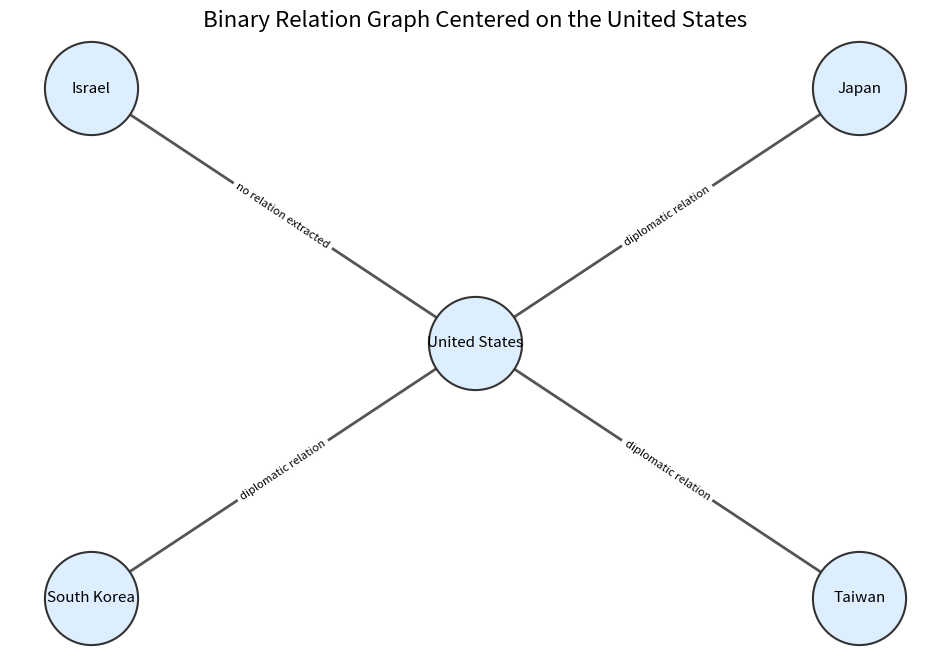

In [ ]:
# 畫出以 United States 為中心的二元關係圖

G = nx.DiGraph()

for _, row in binary_relation_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        relation=row["relation"]
    )

pos = {
    "United States": (0, 0),
    "Israel": (-1.5, 1),
    "Japan": (1.5, 1),
    "South Korea": (-1.5, -1),
    "Taiwan": (1.5, -1)
}

plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500,
    node_color="#DDEEFF",
    edgecolors="#333333",
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=22,
    width=2,
    edge_color="#555555"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "relation")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Binary Relation Graph Centered on the United States", fontsize=16)
plt.axis("off")
plt.show()

小結：REBEL 可以協助自動抽取關係，<br/>
但對中文翻譯後的隱喻文本，抽取結果偏籠統，較難捕捉「依賴、控制、保護、合作」等細緻關係。

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
model = AutoModelForSequenceClassification.from_pretrained("bert-base-chinese")
re_model = pipeline("text-classification", model=model, tokenizer=tokenizer)

re_results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
re_results_df['sentence'] = metaData['sentence']

def get_re_result(sentence):
    # 確保輸入句子的長度不超過模型最大限制，避免 RuntimeError
    result = re_model([sentence], truncation=True, max_length=512)
    return pd.Series([result[0]['label'], result[0]['score']])

re_results_df[['label', 'score']] = metaData['sentence'].apply(get_re_result)

re_results_df.head(10)

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,sentence,label,score
0,聯合 台股大盤漲基層無感 雞腿便當 帳單漲有感 聯合報 葉德正 新北即時報導 台股屢創新高 ...,LABEL_1,0.622981
1,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,LABEL_1,0.588179
2,干你中分龜頭 都 了還在韌性台灣 經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災事件 強力譴責...,LABEL_1,0.556542
3,媒體來源 自由時報 葛祐豪 完整標題 台積電高雄廠 奈米量產 市府 高雄躍升全球先進半導體製...,LABEL_1,0.583606
4,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,LABEL_1,0.547457
5,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...,LABEL_1,0.510309
6,媒體來源 聯合 聯合報 徐白櫻 高雄即時報導 完整標題 台積電高雄 奈米廠正式量產 新增 匝...,LABEL_1,0.545407
7,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...,LABEL_0,0.545434
8,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...,LABEL_1,0.558884
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...,LABEL_1,0.679132


## ＃5.Text Clustering

#### 5.1 基本用法：BERTopic 中文社群文本完整流程

In [ ]:
origin_data = pd.read_csv('./S3-2.csv')

In [ ]:
import re
import jieba
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# 1. 資料前處理
# =========================

# 去除一些不需要的欄位
# Retain 'artCatagory' as it is needed later for display
metaData = origin_data.drop(
    ['artPoster'],
    axis=1
)

# 文章內容轉成文字
metaData['artContent_clean'] = metaData['artContent'].astype(str)

# 移除網址
metaData['artContent_clean'] = metaData['artContent_clean'].str.replace(
    r'https?://\S+|www\.\S+',
    ' ',
    regex=True
)

# 移除 PTT 常見 from / 來源網址殘留
metaData['artContent_clean'] = metaData['artContent_clean'].str.replace(
    r'from\s*\S+',
    ' ',
    regex=True
)

# 將換行轉成空白
metaData['sentence'] = metaData['artContent_clean'].str.replace(
    r'\n+',
    ' ',
    regex=True
)

# 保留中文、英文與空白；其他符號轉成空白
metaData['sentence'] = metaData['sentence'].apply(
    lambda x: re.sub(r'[^A-Za-z\u4e00-\u9fff\s]+', ' ', str(x))
)

# 合併多個空白
metaData['sentence'] = metaData['sentence'].apply(
    lambda x: re.sub(r'\s+', ' ', str(x)).strip()
)

# 移除空白文章
metaData = metaData[metaData['sentence'] != ""].copy()

metaData.head(10)

,system_id,content,artTitle,artContent,artUrl,artCatagory,artDate,embeddings,content_length,artContent_clean,sentence
0,1,台股大盤漲基層無感雞腿便當130 帳單 聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感...,台股大盤漲基層無感雞腿便當130 帳單,聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感 2026 01 01 08 32 聯合...,https://www.ptt.cc/bbs/Gossiping/M.1767227804....,Gossiping,2026-01-01 08:36:41,[-3.33245397e-02 -2.62892455e-01 4.87256311e-...,734,聯合 台股大盤漲基層無感 雞腿便當130 帳單漲有感 2026 01 01 08 32 聯合...,聯合 台股大盤漲基層無感 雞腿便當 帳單漲有感 聯合報 葉德正 新北即時報導 台股屢創新高 ...
1,2,問卦 美國版的我們這一家這樣行嗎 美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美...,問卦 美國版的我們這一家這樣行嗎,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,https://www.ptt.cc/bbs/Gossiping/M.1767228682....,Gossiping,2026-01-01 08:51:20,[-2.14858159e-01 -2.34645665e-01 3.45769912e-...,913,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...
2,3,問卦 韌性是可以多萬用 不膩嗎 干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台...,問卦 韌性是可以多萬用 不膩嗎,干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災...,https://www.ptt.cc/bbs/Gossiping/M.1767230877....,Gossiping,2026-01-01 09:27:55,[-2.70269006e-01 -2.89724499e-01 1.88032672e-...,125,干你中分龜頭 都2026了還在韌性台灣 2025經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災...,干你中分龜頭 都 了還在韌性台灣 經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災事件 強力譴責...
3,4,台積電高雄廠2奈米量產市府 高雄躍升全 1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台...,台積電高雄廠2奈米量產市府 高雄躍升全,1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台積電高雄廠2奈米量產 市府 高雄躍升全球...,https://www.ptt.cc/bbs/Gossiping/M.1767236731....,Gossiping,2026-01-01 11:05:29,[ 1.22327559e-01 -1.93230018e-01 2.29706198e-...,934,1 媒體來源 自由時報 2 葛祐豪 3 完整標題 台積電高雄廠2奈米量產 市府 高雄躍升全球...,媒體來源 自由時報 葛祐豪 完整標題 台積電高雄廠 奈米量產 市府 高雄躍升全球先進半導體製...
4,5,RE 台股大盤漲基層無感雞腿便當130 帳單 不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母...,RE 台股大盤漲基層無感雞腿便當130 帳單,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,https://www.ptt.cc/bbs/Gossiping/M.1767238166....,Gossiping,2026-01-01 11:29:24,[-2.29699641e-01 -3.94749165e-01 1.36889040e-...,145,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...
5,6,RE 問卦 經濟學人 台灣應思考開戰後美不出兵應 早在川普上任之前就有說法好嗎 到底為什麼還...,RE 問卦 經濟學人 台灣應思考開戰後美不出兵應,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...,https://www.ptt.cc/bbs/Gossiping/M.1767239036....,Gossiping,2026-01-01 11:43:54,[-7.74645329e-01 -2.95131892e-01 -2.30428074e-...,155,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...
6,7,台積電高雄2奈米廠正式量產新增2匝道及 1 媒體來源 聯合 2 2026 01 01 10 ...,台積電高雄2奈米廠正式量產新增2匝道及,1 媒體來源 聯合 2 2026 01 01 10 56 聯合報 徐白櫻 高雄即時報導 3 ...,https://www.ptt.cc/bbs/Gossiping/M.1767245019....,Gossiping,2026-01-01 13:23:37,[ 5.19942567e-02 -1.67467713e-01 5.22609614e-...,851,1 媒體來源 聯合 2 2026 01 01 10 56 聯合報 徐白櫻 高雄即時報導 3 ...,媒體來源 聯合 聯合報 徐白櫻 高雄即時報導 完整標題 台積電高雄 奈米廠正式量產 新增 匝...
7,8,問卦 2025台灣有完成什麼大事嗎 一整年如果認真應該可以完成不少事 何況預算又創新高 不然...,問卦 2025台灣有完成什麼大事嗎,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...,https://www.ptt.cc/bbs/Gossiping/M.1767245060....,Gossiping,2026-01-01 13:24:18,[-2.65180469e-01 -3.13053519e-01 2.11296439e-...,220,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...
8,9,RE 新規必看 千坪大樓必須裝太陽光電 要能承受17級強陣風 築 颱 行 示 大 上 每 屋...,RE 新規必看 千坪大樓必須裝太陽光電 要能承受17級強陣風,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...,https://www.ptt.cc/bbs/Gossiping/M.1767246829....,Gossiping,2026-01-01 13:53:47,[-2.03370452e-01 -3.17905217e-01 -1.84581637e-...,123,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...
9,10,RE 問卦 AI訓練為什麼一定要記憶體 因為大模型在運算的時候要把整個模型載入記憶體才能運作...,RE 問卦 AI訓練為什麼一定要記憶體,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...,https://www.ptt.cc/bbs/Gossiping/M.1767253942....,Gossiping,2026-01-01 15:52:20,[-2.12807357e-01 -3.38331312e-01 2.89467007e-...,179,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...


In [ ]:
jieba.set_dictionary('./dict/dict.txt.big')
jieba.load_userdict('./dict/user_dict.txt')

with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

custom_words = [
    "台積電", "輝達", "NVIDIA", "AI", "半導體", "晶片",
    "國安基金", "台股", "美股", "財報", "川普",
    "以色列", "伊朗", "中東", "美國", "日本", "南韓",
    "中國", "台灣", "關稅", "資料中心", "量子電腦",
    "輝達",
    "黃仁勳",
    "AI晶片",
    "AI伺服器",
    "GPU",
    "GB200",
    "GB300",
    "H100",
    "H200",
    "B200",
    "BLACKWELL",
    "COWOS",
    "廣達",
    "緯創",
    "緯穎",
    "鴻海",
    "奇鋐",
    "雙鴻",
    "健策",
    "台達電"
]

for word in custom_words:
    jieba.add_word(word)

stop_words = set([
    "就是", "一個", "真的", "如果", "可以", "還是", "不是",
    "應該", "覺得", "知道", "現在", "今天", "大家", "有人",
    "這樣", "那個", "這個", "什麼", "怎麼", "為什麼",
    "有沒有", "是不是", "因為", "所以", "但是", "而且",
    "然後", "其實", "可能", "感覺", "比較", "一堆",
    "很多", "一直", "已經", "不要", "我們", "他們",
    "你們", "自己", "出來", "看到", "聽說", "如題", "八卦",
    "新聞", "完整", "媒體", "記者", "來源", "備註", "文章",
    "刪除", "違者", "時間", "表示", "問題", "結果",
    "備註請放最後面", "違者新聞文章刪除", "媒體來源",
    "新頭殼", "記者署名", "張柏源綜合報導", "完整新聞標題","yahoo","msn","line","Yahoo","Msn","Line"
])

# 合併 stopwords，並移除重複值
stop_words = list(set(stopWords).union(stop_words))

# jieba 斷詞函數
def jieba_tokenizer(text):
    words = jieba.lcut(str(text))
    words = [
        w for w in words
        if len(w) >= 2
        and w not in stop_words
        and not w.isspace()
    ]
    return words

Building prefix dict from /content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/社群媒體分析/SMA_2026S-main/S3-week11/dict/dict.txt.big ...
Loading model from cache /tmp/jieba.u9ba51f89eaf59b988c28628abc3f894d.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.u9ba51f89eaf59b988c28628abc3f894d.cache
Loading model cost 4.283 seconds.
DEBUG:jieba:Loading model cost 4.283 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [ ]:
# =========================
# 3. BERTopic 建模
# =========================

# 使用前面清理後的文章欄位
docs = metaData['sentence'].dropna().astype(str).tolist()[:500]

# Embedding layer
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 先將文章轉成 embeddings
embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True
)

# Clustering layer
hdbscan_model = HDBSCAN(
    min_cluster_size=8,
    min_samples=2,
    prediction_data=True
)

# Tokenize / representation layer
vectorizer_model = CountVectorizer(
    tokenizer=jieba_tokenizer,
    token_pattern=None,
    stop_words=list(stop_words),
    min_df=2,
    max_df=0.85
)

# BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    top_n_words=15,
    verbose=True
)

# 使用 BERTopic 進行主題模型建立
topics, probs = topic_model.fit_transform(docs, embeddings)

# 查看主題結果
topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-17 11:57:50,086 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 11:57:51,942 - BERTopic - Dimensionality - Completed ✓
2026-05-17 11:57:51,945 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 11:57:51,984 - BERTopic - Cluster - Completed ✓
2026-05-17 11:57:51,988 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 11:58:00,045 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,53,-1_移工_工作_青鳥_雇主,"[移工, 工作, 青鳥, 雇主, 薪資, 勞動, 萬元, 產業, 強迫, 工程師, 經濟, ...",[鉅亨網 黃皓宸 賴清德 今年國民所得可望突破 萬美元 兆國防預算與鄰國比並無偏高 賴清德總...
1,0,159,0_股票_台股_股市_南韓,"[股票, 台股, 股市, 南韓, 億元, 上漲, 外資, 股價, 市場, 台積, 投資人, ...",[媒體來源 TVBS 謝佩穎 完整標題 台股瘋馬秀 開盤大漲 點刷新高 台積電攻 元新天價 ...
2,1,30,1_伊朗_以色列_台股_無人機,"[伊朗, 以色列, 台股, 無人機, 戰爭, 飛彈, 攻擊, 中東, 川普, 聯手, 發動,...",[共三小啊 全伊朗的人都在爽川普出手解決獨裁穆斯林統治者 只有被洗腦的政確智障才會在那邊覺得...
3,2,30,2_機器人_算力_伺服器_模型,"[機器人, 算力, 伺服器, 模型, 用電, 人類, 設備, 台電, 資料中心, 記憶體, ...",[半導體 AI 太吃電 台電估未來五年新增逾 GW 用電 挑戰前所未見 經濟日報 江睿智 台...
4,3,27,3_關稅_川普_晶片_貿易,"[關稅, 川普, 晶片, 貿易, 美方, 協議, 全球, 條款, 法律, 投資, 產業, 官...",[強硬反擊 歐洲議會暫停審議美關稅 聯合報 編譯王曉伯 盧思綸 羅方妤 綜合報導 歐洲議會原...
5,4,26,4_經濟_有錢_亞洲_總統,"[經濟, 有錢, 亞洲, 總統, 成長率, 大陸, 獲利, 日本, 家庭, 臺灣, 萬台幣,...",[請放最後面 違者文章 媒體來源 UDN 賴錦宏 完整標題 陸博主稱台灣年終獎羨煞人 網友 ...
6,5,24,5_監控_大陸_基金_主權,"[監控, 大陸, 基金, 主權, 中共, 發生, 反觀, 韌性, 戰爭, 美國政府, 搶走,...",[小弟百思不得其解 為什麼台灣沒有自己的主權基金 寧願把錢拿去普發掉 主權基金拿去買台積電A...
7,6,22,6_工程師_收入_薪水_文組,"[工程師, 收入, 薪水, 文組, 律師, 教育, 工作, 年薪, 畢業, 醫師, 台大, ...",[最近環工系辦同學會 當然我這個環工逃兵還是如約而至 畢竟 年沒辦同學會了 大概 的人都到了...
8,7,20,7_韓國_日本_反正_音樂,"[韓國, 日本, 反正, 音樂, 財團, 壟斷, 中華電信, 便宜, 臺灣, 垃圾, 台股,...",[日本上次偷台積電事件後 韓國當初也希望台積電滅掉 這樣三X將成為第二供應商 台灣如果和中國...
9,8,16,8_棒球_驕傲_冠軍_輪班,"[棒球, 驕傲, 冠軍, 輪班, 國家隊, 新竹縣, 環境, 球員, 活動, 日本, 改變,...",[去年陳傑憲 強冠軍後 給木曜四受訪 說會想讓兒子唸書當工程師 去台積電之類的 連台灣隊長都...


In [ ]:
# 舉例列出Topic 6的關鍵字和其對應的c TF-IDF分數
topic_model.get_topic(6)

[('工程師', np.float64(0.08203397703149978)),
 ('收入', np.float64(0.06099557305813516)),
 ('薪水', np.float64(0.054005685541648245)),
 ('文組', np.float64(0.052683751625152625)),
 ('律師', np.float64(0.049590034739736326)),
 ('教育', np.float64(0.04892127622645137)),
 ('工作', np.float64(0.04888990250792389)),
 ('年薪', np.float64(0.04747268924385487)),
 ('畢業', np.float64(0.04390312635429385)),
 ('醫師', np.float64(0.041787963717958)),
 ('台大', np.float64(0.040573664787057)),
 ('林智群', np.float64(0.03912673906504838)),
 ('理組', np.float64(0.035712932416677966)),
 ('財金', np.float64(0.0349330860036566)),
 ('焚化爐', np.float64(0.0349330860036566))]

In [ ]:
# 列出前10筆文章的BERTopic資訊
doc_topic_info = topic_model.get_document_info(docs)
doc_topic_info.head(10)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,聯合 台股大盤漲基層無感 雞腿便當 帳單漲有感 聯合報 葉德正 新北即時報導 台股屢創新高 ...,0,0_股票_台股_股市_南韓,"[股票, 台股, 股市, 南韓, 億元, 上漲, 外資, 股價, 市場, 台積, 投資人, ...",[媒體來源 TVBS 謝佩穎 完整標題 台股瘋馬秀 開盤大漲 點刷新高 台積電攻 元新天價 ...,股票 - 台股 - 股市 - 南韓 - 億元 - 上漲 - 外資 - 股價 - 市場 - 台...,1.000000,False
1,美國 以色列 日本 南韓 台灣 關係網用親屬關係來區分 美國 家族中的 SUGAR DADD...,1,1_伊朗_以色列_台股_無人機,"[伊朗, 以色列, 台股, 無人機, 戰爭, 飛彈, 攻擊, 中東, 川普, 聯手, 發動,...",[共三小啊 全伊朗的人都在爽川普出手解決獨裁穆斯林統治者 只有被洗腦的政確智障才會在那邊覺得...,伊朗 - 以色列 - 台股 - 無人機 - 戰爭 - 飛彈 - 攻擊 - 中東 - 川普 -...,0.461484,False
2,干你中分龜頭 都 了還在韌性台灣 經歷了賤賣台積電 馬太鞍偃塞湖事件 台南風災事件 強力譴責...,5,5_監控_大陸_基金_主權,"[監控, 大陸, 基金, 主權, 中共, 發生, 反觀, 韌性, 戰爭, 美國政府, 搶走,...",[小弟百思不得其解 為什麼台灣沒有自己的主權基金 寧願把錢拿去普發掉 主權基金拿去買台積電A...,監控 - 大陸 - 基金 - 主權 - 中共 - 發生 - 反觀 - 韌性 - 戰爭 - 美...,1.000000,False
3,媒體來源 自由時報 葛祐豪 完整標題 台積電高雄廠 奈米量產 市府 高雄躍升全球先進半導體製...,14,14_量子_運算_高速_量子電腦,"[量子, 運算, 高速, 量子電腦, 高雄, 位元, 合作, 製程, 未來, 發展, 市府,...",[請放最後面 違者文章 媒體來源 中時網 崔慈悌 完整標題 賴清德推動量子國家隊 馬汀尼斯盼...,量子 - 運算 - 高速 - 量子電腦 - 高雄 - 位元 - 合作 - 製程 - 未來 -...,1.000000,False
4,不存股的人就跟大雄一樣是廢物 你沒辦法選擇父母 但你可以選擇存股 好好選積優電子股 趁股價下...,0,0_股票_台股_股市_南韓,"[股票, 台股, 股市, 南韓, 億元, 上漲, 外資, 股價, 市場, 台積, 投資人, ...",[媒體來源 TVBS 謝佩穎 完整標題 台股瘋馬秀 開盤大漲 點刷新高 台積電攻 元新天價 ...,股票 - 台股 - 股市 - 南韓 - 億元 - 上漲 - 外資 - 股價 - 市場 - 台...,1.000000,False
5,早在川普上任之前就有說法好嗎 到底為什麼還在相信美國 美國這麼多歷史藉戰爭發財 最近一次烏克...,12,12_戰爭_利益_軍費_川普,"[戰爭, 利益, 軍費, 川普, 台海, 武器, 看過, 俄羅斯, 美元, 轉移, 放棄, ...",[很多人因為很少遇見沒有禮貌的人 被那種惡霸式的行徑給唬住了 以為這叫硬這叫強悍 我住在美國...,戰爭 - 利益 - 軍費 - 川普 - 台海 - 武器 - 看過 - 俄羅斯 - 美元 - ...,1.000000,False
6,媒體來源 聯合 聯合報 徐白櫻 高雄即時報導 完整標題 台積電高雄 奈米廠正式量產 新增 匝...,14,14_量子_運算_高速_量子電腦,"[量子, 運算, 高速, 量子電腦, 高雄, 位元, 合作, 製程, 未來, 發展, 市府,...",[請放最後面 違者文章 媒體來源 中時網 崔慈悌 完整標題 賴清德推動量子國家隊 馬汀尼斯盼...,量子 - 運算 - 高速 - 量子電腦 - 高雄 - 位元 - 合作 - 製程 - 未來 -...,0.934899,False
7,一整年如果認真應該可以完成不少事 何況預算又創新高 不然過去八年累積下來 應該會有什麼重大建...,10,10_短缺_稀土_中華隊_發動機,"[短缺, 稀土, 中華隊, 發動機, 晶片, 路透, 技術, 製造商, 領先, 原料, 生產...",[阿肥剛剛在看棒球討論啦 大家又在檢討中華隊 突然想到一件事 台灣最成功的公司應該就是 台積...,短缺 - 稀土 - 中華隊 - 發動機 - 晶片 - 路透 - 技術 - 製造商 - 領先 ...,0.870464,False
8,築 颱 行 示 大 上 每 屋 評 利 類 足 模 新 出 條 評 家 需 有專家知道大概還...,-1,-1_移工_工作_青鳥_雇主,"[移工, 工作, 青鳥, 雇主, 薪資, 勞動, 萬元, 產業, 強迫, 工程師, 經濟, ...",[鉅亨網 黃皓宸 賴清德 今年國民所得可望突破 萬美元 兆國防預算與鄰國比並無偏高 賴清德總...,移工 - 工作 - 青鳥 - 雇主 - 薪資 - 勞動 - 萬元 - 產業 - 強迫 - 工...,0.000000,False
9,因為大模型在運算的時候要把整個模型載入記憶體才能運作 那你猜猜為什麼叫大模型 就是靠北大 我...,2,2_機器人_算力_伺服器_模型,"[機器人, 算力, 伺服器, 模型, 用電, 人類, 設備, 台電, 資料中心, 記憶體, ...",[半導體 AI 太吃電 台電估未來五年新增逾 GW 用電 挑戰前所未見 經濟日報 江睿智 台...,機器人 - 算力 - 伺服器 - 模型 - 用電 - 人類 - 設備 - 台電 - 資料中心...,0.619020,False


In [ ]:
# 視覺化主題分布：圓圈大小是主題的大小，圓圈的距離是主題之間的相似度
topic_model.visualize_topics()

In [ ]:
# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = topic_model.approximate_distribution(docs)

100%|██████████| 1/1 [00:14<00:00, 14.52s/it]


In [ ]:
# 以第18個文件為例，列出這份文件對每個主題的機率分布
topic_model.visualize_distribution(topic_distr[18])

查看特定文章的主題分佈

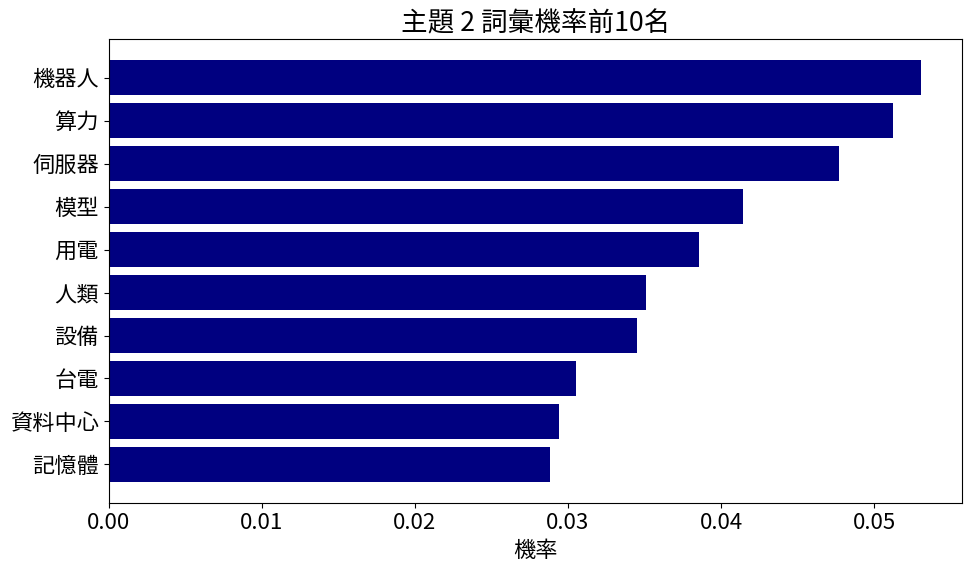

In [ ]:
from matplotlib.font_manager import fontManager
import matplotlib.pyplot as plt

font_path = "./TaipeiSansTCBeta-Regular.ttf"

fontManager.addfont(font_path)

plt.rcParams["font.sans-serif"] = ["Taipei Sans TC Beta"]
plt.rcParams["axes.unicode_minus"] = False


# 視覺化顯示主題-詞彙分佈
topic_n = 2
data = topic_model.get_topic(topic_n)

# 轉換為 DataFrame
df = pd.DataFrame(data, columns=["word", "prob"])
df = df[df["word"] != " "]

# 根據 prob 排序並選出前 10 名
top_10 = df.sort_values("prob", ascending=False).head(10)

# 畫出長條圖
plt.figure(figsize=(10, 6))
plt.barh(top_10["word"], top_10["prob"], color="navy")
plt.xlabel("機率")
plt.title(f"主題 {topic_n} 詞彙機率前10名")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 5.2 不同 Embedding Model 比較<br>
BERTopic 支援多種 embedding 模型與方法，包含基本的 Huggingface 模型，也提供了 LLM-based 的 embedding 可做選擇。<br>
更多請參考文件：https://maartengr.github.io/BERTopic/getting_started/embeddings/embeddings.html#scikit-learn-embeddings

In [ ]:
# BERTopic 使用的文章資料
docs = metaData['sentence'].dropna().tolist()

# CountVectorizer 使用 jieba tokenizer
vectorizer_model = CountVectorizer(
    tokenizer=jieba_tokenizer,
    token_pattern=None,
    stop_words=list(stop_words),
    min_df=2,
    max_df=0.85
)

# Embedding model
sentence_model = SentenceTransformer("distiluse-base-multilingual-cased-v2")

# 分群模型
hdbscan_model = HDBSCAN(
    min_cluster_size=8,
    min_samples=2,
    prediction_data=True
)

# 建立 BERTopic
embed_topic_model = BERTopic(
    embedding_model=sentence_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual"
)

# 訓練模型
topics, probs = embed_topic_model.fit_transform(docs[:500])

# 查看主題結果
embed_topic_model.get_topic_info()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,98,-1_量子_台灣_青鳥_運算,"[量子, 台灣, 青鳥, 運算, 臺灣, 國家, 科技, 國家隊, 韌性, 未來]",[跟半導體串接加速布局 國科會本周公布高速量子國家戰略 聯合報 董俞佳 台北報導 國科會今舉...
1,0,43,0_工程師_文組_收入_工作,"[工程師, 文組, 收入, 工作, 畢業, 年薪, 律師, 教育, 醫師, 薪水]",[最近環工系辦同學會 當然我這個環工逃兵還是如約而至 畢竟 年沒辦同學會了 大概 的人都到了...
2,1,41,1_進場_台股_明天_美股,"[進場, 台股, 明天, 美股, 剛剛, 慶祝, 開盤, 說好, 幾天, 股價]",[剛剛看消息說好像要開會考慮國安基金進場 但現在明明就創新高 萬 千點了 還要護盤是不是很奇...
3,2,37,2_台灣_缺電_發電_便宜,"[台灣, 缺電, 發電, 便宜, 有錢, 美國, 外資, 世界, 基金, jptt]",[今天我看到一個對岸的 對岸的高空發電S 已經升到 米成功商轉 發電量 GW 就這個 上面是...
4,3,34,3_伊朗_以色列_美國_台股,"[伊朗, 以色列, 美國, 台股, 市值, 金河, 戰爭, 無人機, 中東, 市場]",[共三小啊 全伊朗的人都在爽川普出手解決獨裁穆斯林統治者 只有被洗腦的政確智障才會在那邊覺得...
5,4,29,4_關稅_台灣_川普_美國,"[關稅, 台灣, 川普, 美國, 貿易, 政府, 協議, 經濟, 國家, 美方]",[請放最後面 違者文章 媒體來源 新頭殼 張柏源綜合報導 完整標題 重談台美協議 王婉諭 代...
6,5,27,5_ai_伺服器_人類_消耗,"[ai, 伺服器, 人類, 消耗, 算力, gpu, 資料中心, 取代, 這場, 太空]",[因為台灣做對最重要的事 減產人類 AI取代人類是地球演化的方向 往這方向發展才有前途 所以...
7,6,25,6_棒球_驕傲_日本_台灣,"[棒球, 驕傲, 日本, 台灣, 冠軍, 環境, 輪班, 努力, 球員, 拿來]",[我們有個惡習啊 基本上沒有努力過什麼 就希望沾光 台灣這幾年有因為 行政措施 的改變 降低...
8,7,24,7_移工_台灣_美國_工作,"[移工, 台灣, 美國, 工作, 勞動, 晶片, 強迫, 雇主, 支付, 川普]",[ETTODAY 羅翊宬 中共恐犯台 美CIA向蘋果輝達 機密簡報 憂晶片供應鏈風險 中國軍...
9,8,19,8_市場_台股_指數_經濟,"[市場, 台股, 指數, 經濟, 億元, 美股, 薪資, 失業率, 投資, 增長]",[媒體來源 ETTODAY 柯振中 綜合報導 完整標題 台股暴跌 國安基金操盤手 必要時不排...


#### 5.3 Clustering model<br>

調整topic modeling 流程中的 clustering 算法<br/>
將原本BERTopic 預設分群方式：HDBSCAN，改成指定分群方式：KMeans<br/>

參考文件：https://maartengr.github.io/BERTopic/getting_started/clustering/clustering.html

In [ ]:
# 使用 KMeans 作為分群算法，需要指定分群個數
cluster_model = KMeans(n_clusters=5)

# 定義不同 layer 所要使用的模型與方法
embedding_model = "paraphrase-multilingual-MiniLM-L12-v2"
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 hdbscan_model 替換為其他模型（cluster_model）
kmeans_topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=cluster_model, vectorizer_model=vectorizer_model)
topics, probs = kmeans_topic_model.fit_transform(docs[:500])

kmeans_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,154,0_億元_台積電_my_sent,"[億元, 台積電, my, sent, from, on, 新台幣, iphone, 有沒有...",[安安安安 是這樣的 如題啦 台積電 兩千塊 是猛在哪 兩千塊掉在地上 小妹我都不一定會多看...
1,1,136,1_完整_sent_from_my,"[完整, sent, from, my, on, 繁體中文字水桶, 未滿, jptt, 台積...",[很多人再洗 台積電漲到多少錢 台灣人人都很有錢 台積電是外資公司 台積電漲到 受益最大的也...
2,2,93,2_完整_蔡委員煌瑯_黃董事長重球_msn等媒體,"[完整, 蔡委員煌瑯, 黃董事長重球, msn等媒體, 不可用yahoo, line, an...",[媒體來源 NEWTALK 莊豐嘉 完整標題 大罷免志工的故事 一個公民代號 一場信任實驗 ...
3,3,62,3_萬元_ai_萬瓩_完整,"[萬元, ai, 萬瓩, 完整, 個月, 或短網址, msn等媒體, 不可用yahoo, l...",[FTNN網 蕭廷芬 綜合報導 台積電工程師被撞成植物人 法院判貨車司機賠 萬元 新竹縣寶山...
4,4,55,4_繁體中文字水桶_未滿_個月_完整,"[繁體中文字水桶, 未滿, 個月, 完整, 點或, 美國, 美元, 億美元, 標普, daddy]",[自由 中東戰火台股昨大跌 謝金河 台企韌性強勁 家市值破千億美元 謝金河指出 雖然台股 日...


查看 text clustering 結果

In [ ]:
topics[:10]

[0, 4, 1, 1, 0, 4, 1, 1, 1, 3]

### 5.4 用模型進行主題標籤的調整
新版本的BERTopic提供許多方法供我們調整以c TF-IDF的主題表示，讓我們能得到更能準確描述各個文件集合的字詞去描述每個主題。<br/>
（意思是讓BERTopic 分完主題之後，如何讓每個主題的「代表關鍵字」更準確）

<br/>
以KeyBERT非生成模型方法做示範如何去調整BERTopic的主題表示詞語

---
KeyBERT是一種文本關鍵字提取模型，其方法是透過計算文本中每個N-gram或者token字詞和文件本身之間得BERT embedding的餘弦相似度，去找到文件的關鍵字。
BERTopic根據KeyBERT的方法去建立了一個應用於每個Topic的關鍵字提取流程，架構如下圖所示。

1. 首先針對Topic n，會先依據這個主題的c TF-IDF去找出最能代表主題的幾篇文件，和最能代表主題的幾個候選關鍵代表字。
    - 候選關鍵代表字是根據c TF-IDF的大小去排序，找出前Ｎ個代表字
    - 主題的代表文件挑選方法是比較主題的c TF-IDF和每篇文件的c TF-IDF
2. 接著會利用BERT去產生這些文件和候選代表字的Embedding向量
    - 其中所有代表文件的Embedding向量會取平均作為這個Topic n的向量表示
3. 接著去計算Topic n的向量表示和每個候選代表字的Embedding向量的相似度去找出這個Topic n的最終代表字

根據這個調整後KeyBERT的方法，就能快速的去調整並找出每個主題的代表關鍵字。

In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# 1. 使用前面清理後的文章資料
# =========================

docs = metaData['sentence'].dropna().astype(str).tolist()[:500]


# =========================
# 2. Embedding layer
# =========================

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 先將文章轉成 embeddings
embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True
)


# =========================
# 3. Clustering layer
# =========================

# 助教版本是 min_cluster_size=5, min_samples=30
# 這裡先照助教邏輯套用
hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=30,
    prediction_data=True
)


# =========================
# 4. Tokenize / representation layer
# =========================

vectorizer_model = CountVectorizer(
    tokenizer=jieba_tokenizer,
    token_pattern=None,
    stop_words=list(stop_words),
    min_df=2,
    max_df=0.85
)


# =========================
# 5. Representation model：KeyBERTInspired
# =========================

keybert = KeyBERTInspired()

representation_model = {
    "KeyBERT": keybert
}


# =========================
# 6. 建立 BERTopic 模型
# =========================

representation_topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="multilingual",
    top_n_words=30,
    verbose=True
)


# =========================
# 7. Train model
# =========================

topics, probs = representation_topic_model.fit_transform(docs, embeddings)


# =========================
# 8. 觀察 KeyBERT 微調後的主題表示
# =========================

representation_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-17 10:07:32,179 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 10:07:33,198 - BERTopic - Dimensionality - Completed ✓
2026-05-17 10:07:33,199 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 10:07:33,219 - BERTopic - Cluster - Completed ✓
2026-05-17 10:07:33,223 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 10:07:37,410 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,KeyBERT,Representative_Docs
0,-1,157,-1_量子_核能_台電_投資,"[量子, 核能, 台電, 投資, 萬元, 中國, 運算, 技術, 全球, 協議, 貿易, 南...","[核能, 量子電腦, 技術, 台電, 委員, 研發, 中國, 發電, 量子, 工程]",[請放最後面 違者文章 媒體來源 中時網 崔慈悌 完整標題 賴清德推動量子國家隊 馬汀尼斯盼...
1,0,172,0_中國_全球_移工_總統,"[中國, 全球, 移工, 總統, 日本, 工作, 企業, 推動, 技術, 韓國, 政策, 供...","[中國, 習近平, 臺灣, 中文, 亞洲, 美方, 韓國, 美國政府, 全球, 議題]",[媒體來源 大紀元網 李淨 駱亞 完整標題 李強報告承認經濟失衡 專家析下滑趨勢難逆轉 完整...
2,1,139,1_一張_美股_失業率_一年,"[一張, 美股, 失業率, 一年, 工作, 回本, 投資, 大漲, 交易, 買超, 投資人,...","[價差, 天價, 飆漲, 年薪, 買超, 收益, 大漲, 花錢, 價格, 主計]",[景氣好股市熱 月失業率 創 年同月新低 中央社潘姿羽台北 日電 主計總處今天公布 年 月失...
3,2,32,2_金河_無人機_飛彈_中國,"[金河, 無人機, 飛彈, 中國, 攻擊, 億美元, 軍費, 發動, 企業, 開盤, 投顧,...","[核彈, 戰火, 俄羅斯, 攻擊, 美軍, 動盪, 總統, 軍事, 全國, 威脅]",[媒體來源 民視 黃于庭 完整標題 川普再出手治獨裁政權 謝金河曝他危險了 這國 說不定與台...


### 5.5 結合 TinyLlama 的生成式主題命名（延伸）

先用 BERTopic 找出主題與關鍵字，<br/>
再用 TinyLlama 幫每個主題取一個中文主題名稱。

**調整原因**<br/>
原先嘗試將 TinyLlama 直接加入 BERTopic 的 representation_model，<br/>
讓模型在主題建模過程中同步產生主題名稱<br/>
<br/>
但實作時發現 BERTopic 在 representation 階段<br/>
會將主題代表文章與關鍵字一起輸入 TinyLlama<br/>
造成 prompt 過長，即使降低 max_new_tokens，<br/>
仍容易因 GPU 記憶體不足而中斷。<br/>
<br/>
因此改採<br/>
**「BERTopic 先完成主題分群與關鍵字萃取，**<br/>
**再用 TinyLlama 進行後處理命名」的方式**<br/>
<br/>
降低 GPU 負擔，提升執行穩定性，<br/>
同時保留生成式模型協助主題命名的優點

```
文章資料 docs
    ↓
BERTopic 分主題
    ↓
每個 topic 產生一組關鍵字
    ↓
把關鍵字丟給 TinyLlama
    ↓
TinyLlama 產生中文主題名稱
    ↓
把主題名稱放回 BERTopic
    ↓
視覺化時顯示自訂主題名稱
```

In [ ]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from bertopic import BERTopic
from hdbscan import HDBSCAN

keybert = KeyBERTInspired()
mmr = MaximalMarginalRelevance(diversity=0.3)

representation_model = {
    "KeyBERT": keybert,
    "MMR": mmr
}

topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=HDBSCAN(
        min_cluster_size=30,
        min_samples=30,
        prediction_data=True
    ),
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="multilingual",
    top_n_words=8,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

topic_info = topic_model.get_topic_info()
topic_info

2026-05-17 10:07:39,786 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-17 10:07:41,630 - BERTopic - Dimensionality - Completed ✓
2026-05-17 10:07:41,632 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-17 10:07:41,665 - BERTopic - Cluster - Completed ✓
2026-05-17 10:07:41,670 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-17 10:07:46,381 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,150,-1_量子_核能_中國_運算,"[量子, 核能, 中國, 運算, 全球, 臺灣, 韌性, 總統]","[量子, 核能, 反核, 中國, 臺灣, 現實, 計畫, 研發, 全球, 韓元]","[量子, 核能, 中國, 全球, 臺灣, 南韓, 戰略, 電力, 企業, 民進黨]",[請放最後面 違者文章 媒體來源 中時網 崔慈悌 完整標題 賴清德推動量子國家隊 馬汀尼斯盼...
1,0,209,0_中國_全球_日本_企業,"[中國, 全球, 日本, 企業, 貿易, 總統, 協議, 韓國]","[中國, 習近平, 中文, 亞洲, 美國政府, 臺灣, 美方, 韓國, 全球, 國防]","[中國, 貿易, 韓國, 美方, 供應鏈, 國會, 民進黨, 談判, gdp, 習近平]",[媒體來源 大紀元網 李淨 駱亞 完整標題 李強報告承認經濟失衡 專家析下滑趨勢難逆轉 完整...
2,1,141,1_回本_etf_持有_天價,"[回本, etf, 持有, 天價, 指期, in, 安安, all]","[賺大錢, 天價, 高價, 收益, 股民, 賣給, 賣掉, 存款, 成交, 買進]","[etf, 天價, 指期, 總處, 站上, 避險, 買進, 賣掉, 學長, 股民]",[媒體來源 FTV 周孟漢報導 完整標題 工程師離職炒股 萬滾成 億 只花 個月 全靠 這玩...


取出 topic 關鍵字

In [ ]:
topic_keywords = {}

# Iterate over all valid topics that BERTopic identified
# topic_model.get_topics() returns a dictionary where keys are topic_ids
for topic_id in topic_model.get_topics().keys():
    # Exclude the outlier topic -1
    if topic_id == -1:
        continue

    words = topic_model.get_topic(topic_id)
    keywords = [word for word, score in words[:10]]
    topic_keywords[topic_id] = keywords

# Display the populated topic_keywords for verification
topic_keywords

{0: ['中國', '全球', '日本', '企業', '貿易', '總統', '協議', '韓國'],
 1: ['回本', 'etf', '持有', '天價', '指期', 'in', '安安', 'all']}

5.5.3 使用 Embedding 相似度重新挑選 Representative Docs


原本 BERTopic 自動產生的 Representative_Docs 不一定最符合主題核心，所以這裡改用 embedding 相似度重新挑選。


```
同一個 topic 裡面
→ 計算所有文章 embedding 的平均向量，作為 topic 中心
→ 計算每篇文章和 topic 中心的 cosine similarity
→ 分數越高，代表越接近該主題核心
```



In [ ]:
# ==========================================
# 5. 使用 embedding 相似度重新挑選代表文章
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 確保 embeddings 是 numpy array
embeddings_array = np.array(embeddings)

# 建立文章與 topic 對應表
doc_topic_df = pd.DataFrame({
    "doc_id": range(len(docs)),
    "doc": docs,
    "topic": topics
})

# 如果 metaData 有原始欄位，補回 system_id、標題、看板等資訊
meta_for_topic = metaData.copy()
meta_for_topic = meta_for_topic[meta_for_topic["sentence"].notna()].copy()
meta_for_topic = meta_for_topic[meta_for_topic["sentence"].astype(str).str.strip() != ""].copy()
meta_for_topic = meta_for_topic.iloc[:len(docs)].copy()
meta_for_topic = meta_for_topic.reset_index(drop=True)

# --- MODIFIED START ---
cols_to_add = ["system_id", "artTitle", "artCatagory", "artDate", "artUrl"]

# Filter meta_for_topic to only include columns that exist and are needed
existing_cols_in_meta = [col for col in cols_to_add if col in meta_for_topic.columns]
meta_cols_to_merge = meta_for_topic[existing_cols_in_meta].copy()

# Ensure doc_topic_df has a column to merge on, which is its current index after creation
doc_topic_df = doc_topic_df.set_index('doc_id')
meta_cols_to_merge.index.name = 'doc_id' # Align index names for merge
doc_topic_df = doc_topic_df.merge(meta_cols_to_merge, left_index=True, right_index=True, how='left')
doc_topic_df = doc_topic_df.reset_index() # Bring doc_id back as a column
# --- MODIFIED END ---

# 加入文章長度，避免太短文本被選為代表文章
doc_topic_df["doc_length"] = doc_topic_df["doc"].astype(str).str.len()

# 可依資料情況調整門檻
doc_topic_df_filtered = doc_topic_df[doc_topic_df["doc_length"] >= 50].copy()

# 建立 topic 關鍵字文字
topic_keywords_map = {
    topic_id: "、".join(keywords)
    for topic_id, keywords in topic_keywords.items()
}

representative_docs_list = []

for topic_id in sorted(doc_topic_df_filtered["topic"].unique()):
    if topic_id == -1:
        continue

    topic_df = doc_topic_df_filtered[
        doc_topic_df_filtered["topic"] == topic_id
    ].copy()

    # 如果該 topic 沒有足夠文章，則略過
    if len(topic_df) == 0:
        continue

    topic_doc_ids = topic_df["doc_id"].tolist()
    topic_embeddings = embeddings_array[topic_doc_ids]

    # 計算 topic 中心向量
    centroid = topic_embeddings.mean(axis=0)

    # 計算每篇文章與 topic 中心的 cosine similarity
    similarities = cosine_similarity(
        topic_embeddings,
        centroid.reshape(1, -1)
    ).flatten()

    topic_df["representative_score"] = similarities
    topic_df["topic_keywords"] = topic_df["topic"].map(topic_keywords_map)

    # 每個 topic 取前 3 篇代表文章
    top_docs = topic_df.sort_values(
        "representative_score",
        ascending=False
    ).head(3)

    representative_docs_list.append(top_docs)

# 合併所有 topic 的代表文章
representative_docs_precise = pd.concat(representative_docs_list).reset_index(drop=True)

display(
    representative_docs_precise[[
        "topic",
        "topic_keywords",
        "representative_score",
        "artCatagory",
        "artTitle",
        "doc"
    ]]
)

,topic,topic_keywords,representative_score,artCatagory,artTitle,doc
0,0,中國、全球、日本、企業、貿易、總統、協議、韓國,0.859160,Gossiping,RE 問卦 為何股版都是預測明天大跌千點的文,相信阿德 中共現在沒能力攻打台灣啊 而且台積電還沒完全變成美積電前 美國阿爸會救台灣啦 千萬...
1,0,中國、全球、日本、企業、貿易、總統、協議、韓國,0.842096,Gossiping,問卦 跟美國硬著幹台積電會漲更高吧,如題 今天台積電 了 很多人都說 台灣太屈服美國 被美國耍著玩 賣企業求榮 根本毀壞中華文明...
2,0,中國、全球、日本、企業、貿易、總統、協議、韓國,0.825469,Gossiping,問卦 台股飆成這樣 其他國家會不會嫉妒啊,如標題 我們台灣因為吃到AI紅利 整個台股飆升驚人 幾乎逼近 萬 千點 台積電更爽 都快 元...
3,1,回本、etf、持有、天價、指期、in、安安、all,0.855664,Gossiping,問卦 這邊持有1張以上台積電的人多嗎,各位大大晚安啦 阿肥發現定期定額一個月扣 的話 只能買 股台積電 一年只能存 股 要存滿一張...
4,1,回本、etf、持有、天價、指期、in、安安、all,0.843003,Gossiping,問卦 台積電2000之後然後呢,一堆分析師說台積電在 年 年左右達到 股價 元 阿現在 而已 已經差不多達到 了 所以接下來...
5,1,回本、etf、持有、天價、指期、in、安安、all,0.834214,Gossiping,問卦 現在ALLIN台積電還來得及嗎,去年買一張好像不太夠 感覺到可惜 台積電這麼好 看到判決書年薪 多萬 去年 月還沒年底的楠梓...


In [ ]:
# ==========================================
# 6. 整理每個 topic 的代表文章
# ==========================================

topic_representative_docs = {}

for topic_id in representative_docs_precise["topic"].unique():
    docs_list = representative_docs_precise[
        representative_docs_precise["topic"] == topic_id
    ]["doc"].tolist()

    topic_representative_docs[topic_id] = docs_list

topic_representative_docs

{np.int64(0): ['相信阿德 中共現在沒能力攻打台灣啊 而且台積電還沒完全變成美積電前 美國阿爸會救台灣啦 千萬別看股版做股票 股版一堆空手蛙跟空蛙 喊爽的',
  '如題 今天台積電 了 很多人都說 台灣太屈服美國 被美國耍著玩 賣企業求榮 根本毀壞中華文明不可取 那跟美國硬幹的政策 台積電會漲更高吧 會到 嗎 我很好奇',
  '如標題 我們台灣因為吃到AI紅利 整個台股飆升驚人 幾乎逼近 萬 千點 台積電更爽 都快 元了 台灣老百姓賺飽飽 笑呵呵 反觀其他國家 像日本韓國或中國大陸等等 根本沒像我們台灣漲的這麼誇張 尤其大陸 經濟還持續下滑 他們這些國家 看到台灣有錢爽到這個樣子 會不會眼紅妒忌我們啊 有沒有台灣吃到AI紅利爽翻天 會不會引來其他國家妒忌我們的啊'],
 np.int64(1): ['各位大大晚安啦 阿肥發現定期定額一個月扣 的話 只能買 股台積電 一年只能存 股 要存滿一張 年欸 而且前提是股價都不動 這樣以後的年輕人怎麼存得到台積電',
  '一堆分析師說台積電在 年 年左右達到 股價 元 阿現在 而已 已經差不多達到 了 所以接下來 全賣掉 找下一隻股票 不賣 但是不賣可能會遇到大回撤喔 不買也不賣 就放著 但是薪水下來要繼續投資台積電嗎 還是買其他的呢',
  '去年買一張好像不太夠 感覺到可惜 台積電這麼好 看到判決書年薪 多萬 去年 月還沒年底的楠梓廠聽說破 當時候避險買了其他股票 通通都沒漲什麼樣 所以台積電是好公司吧 雖然現在已經 了 但是看在未來 是不是應該ALL IN台積電了']}

用 TinyLlama 命名

In [ ]:
# ==========================================
# 7. TinyLlama 主題命名函式
# ==========================================

import re

def clean_topic_name(text):
    text = str(text).strip()
    text = text.split("\n")[0].strip()

    remove_words = [
        "主題名稱：", "主題名稱:", "答案：", "答案:",
        "可以命名為", "可命名為", "建議命名為",
        "以下是", "：", ":"
    ]

    for w in remove_words:
        text = text.replace(w, "")

    text = re.sub(r"[「」『』\"'`。,.，、]+", "", text)
    text = text.strip()

    return text[:12]

In [ ]:
# ==========================================
# 8. 使用關鍵字 + 代表文章產生主題名稱
# ==========================================

from transformers import pipeline
import torch

def shorten_doc(text, max_chars=100):
    text = str(text).replace("\n", " ")
    return text[:max_chars]

# Initialize TinyLlama pipeline for text generation
# It's better to load the model once globally if it's used multiple times.
generator = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

def generate_topic_name(keywords, representative_docs):
    # 只取前 2 篇代表文章，避免 prompt 太長
    short_docs = representative_docs[:2]

    docs_text = "\n".join([
        f"- {shorten_doc(doc, max_chars=100)}"
        for doc in short_docs
    ])

    prompt = f"""
你是一位金融業的社群媒體分析研究助理。
請根據下列主題關鍵字與代表文章，產生一個中文主題名稱。

主題關鍵字：{", ".join(keywords)}

代表文章：
{docs_text}

規則：
只輸出一個主題名稱。
不要解釋。
不要列點。
不要超過8個中文字。
主題名稱要適合放在社群媒體分析報告中。

主題名稱：
"""

    result = generator(
        prompt,
        max_new_tokens=20,
        do_sample=False,
        return_full_text=False
    )

    return clean_topic_name(result[0]["generated_text"])

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# 9. 逐一產生每個 topic 的主題名稱
# ==========================================

tinyllama_labels = {}

for topic_id, keywords in topic_keywords.items():
    representative_docs = topic_representative_docs.get(topic_id, [])

    tinyllama_labels[topic_id] = generate_topic_name(
        keywords=keywords,
        representative_docs=representative_docs
    )

tinyllama_labels

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=20) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{0: '台灣屈服美國股票做', 1: '回本 etf 持有 天價'}

In [ ]:
# ==========================================
# 10. 建立主題命名檢查表
# ==========================================

topic_label_check = []

for topic_id, keywords in topic_keywords.items():
    rep_docs = topic_representative_docs.get(topic_id, [])

    topic_label_check.append({
        "topic": topic_id,
        "topic_keywords": "、".join(keywords),
        "representative_doc_1": shorten_doc(rep_docs[0], 120) if len(rep_docs) > 0 else "",
        "representative_doc_2": shorten_doc(rep_docs[1], 120) if len(rep_docs) > 1 else "",
        "tinyllama_label": tinyllama_labels.get(topic_id, "")
    })

topic_label_check_df = pd.DataFrame(topic_label_check)

display(topic_label_check_df)

,topic,topic_keywords,representative_doc_1,representative_doc_2,tinyllama_label
0,0,中國、全球、日本、企業、貿易、總統、協議、韓國,相信阿德 中共現在沒能力攻打台灣啊 而且台積電還沒完全變成美積電前 美國阿爸會救台灣啦 千萬...,如題 今天台積電 了 很多人都說 台灣太屈服美國 被美國耍著玩 賣企業求榮 根本毀壞中華文明...,台灣屈服美國股票做
1,1,回本、etf、持有、天價、指期、in、安安、all,各位大大晚安啦 阿肥發現定期定額一個月扣 的話 只能買 股台積電 一年只能存 股 要存滿一張...,一堆分析師說台積電在 年 年左右達到 股價 元 阿現在 而已 已經差不多達到 了 所以接下來...,回本 etf 持有 天價


放回 BERTopic

In [ ]:
# ==========================================
# 11. 將 TinyLlama 命名結果放回 BERTopic
# ==========================================

topic_model.set_topic_labels(tinyllama_labels)

topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,KeyBERT,MMR,Representative_Docs
0,-1,150,-1_量子_核能_中國_運算,-1_量子_核能_中國_運算,"[量子, 核能, 中國, 運算, 全球, 臺灣, 韌性, 總統]","[量子, 核能, 反核, 中國, 臺灣, 現實, 計畫, 研發, 全球, 韓元]","[量子, 核能, 中國, 全球, 臺灣, 南韓, 戰略, 電力, 企業, 民進黨]",[請放最後面 違者文章 媒體來源 中時網 崔慈悌 完整標題 賴清德推動量子國家隊 馬汀尼斯盼...
1,0,209,0_中國_全球_日本_企業,台灣屈服美國股票做,"[中國, 全球, 日本, 企業, 貿易, 總統, 協議, 韓國]","[中國, 習近平, 中文, 亞洲, 美國政府, 臺灣, 美方, 韓國, 全球, 國防]","[中國, 貿易, 韓國, 美方, 供應鏈, 國會, 民進黨, 談判, gdp, 習近平]",[媒體來源 大紀元網 李淨 駱亞 完整標題 李強報告承認經濟失衡 專家析下滑趨勢難逆轉 完整...
2,1,141,1_回本_etf_持有_天價,回本 etf 持有 天價,"[回本, etf, 持有, 天價, 指期, in, 安安, all]","[賺大錢, 天價, 高價, 收益, 股民, 賣給, 賣掉, 存款, 成交, 買進]","[etf, 天價, 指期, 總處, 站上, 避險, 買進, 賣掉, 學長, 股民]",[媒體來源 FTV 周孟漢報導 完整標題 工程師離職炒股 萬滾成 億 只花 個月 全靠 這玩...


In [ ]:
# ==========================================
# 12. 使用 TinyLlama 主題名稱進行視覺化
# ==========================================

topic_model.visualize_documents(
    docs,
    custom_labels=True
)

本研究使用 BERTopic 進行社群文本主題分群，並進一步使用 TinyLlama 協助主題命名。雖然此流程能夠自動萃取文章中的潛在主題，但由於 PTT 文章內容具有高度混雜性，且原始資料中可能同時包含股市、國際政治、科技新聞與社會評論等不同語境，因此模型產生的部分主題可能與本研究原先聚焦的 NVIDIA／AI 晶片熱潮並非完全一致。<br/>
<br/>
若後續希望提升主題命名與分析結果的精準度，應在 BERTopic 分群前先進一步篩選資料，保留與「晶片」、「AI 晶片」、「輝達」、「NVIDIA」、「GPU」、「AI 伺服器」等核心關鍵詞直接相關的文章，再針對這些較聚焦的文本重新進行主題分群。如此一來，BERTopic 產生的 topic 會更集中於 NVIDIA 與 AI 晶片討論，而 TinyLlama 進行主題命名時，也能根據更精準的主題關鍵字與代表文章，產生更符合研究目的的 NLP 主題名稱。